In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

In [2]:
df = pd.read_csv('../Village_Wise_Data/Kalewal.csv')

In [3]:
df.head()

,Timestamp,Survey type,Village Name,Household ID (House No.),Name of Head of Household,Gender,Contact Number of Household,Social Category,Total Family Members,Main Occupation,...,Livelihood Schemes [PM Fasal Bima],Livelihood Schemes [Pension Schemes],Awareness about Gram Sabha meetings,Participation in village development,Major village issues,Most urgent need of the village,Suggestions for village development,Enumerator Name,UID,Date
0,1/16/2026 13:13:04,Baseline,Kalewal,2,Jasweer singh,Male,9417537358,General,4.0,Service,...,Not Aware,Not Aware,No,Never,Environment,NaN,NaN,Akshay,25BAV10127,1/16/2026
1,1/16/2026 13:36:58,Baseline,Kalewal,NaN,Gandeep kaur,Female,9779717680,OBC,5.0,Agriculture,...,Not Aware,Not Aware,Yes,Occasional,"Water, Health, Education, Employment, Environment",Road and electricity,Sewage,Abhijeet,25bav10097,1/16/2026
2,1/16/2026 13:50:00,Baseline,Kalewal,NaN,Gaganpreet Singh,Male,7527923647,OBC,6.0,Agriculture,...,Not Aware,Aware,Yes,Regular,"Water, Health, Education, Employment, Environment",Road problems,Sewage improvement,Milan Sangwan,25BAV10233,1/16/2026
3,1/16/2026 14:04:31,Baseline,Kalewal,NaN,Baljeet,Male,9878275094,OBC,9.0,Service,...,Not Aware,Applied,Yes,Never,"Water, Environment",Road issues,Sewage problems,Himakshi,25BAV10037,1/16/2026
4,1/16/2026 14:14:53,Baseline,Kalewal,NaN,Ramandeep Kumar,Male,9815438371,General,5.0,Service,...,Aware,Availed,Yes,Regular,Employment,"Drugs issue, road problems",Sewage issues,Naisha Sharma,24BAV10037,1/16/2026


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (44, 75)


In [5]:
df.columns = df.columns.str.strip()
df['Total Family Members'] = pd.to_numeric(df['Total Family Members'], errors='coerce')

In [6]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column Name', 'Missing Count']
missing_values[missing_values['Missing Count'] > 0]

,Column Name,Missing Count
3,Household ID (House No.),18
6,Contact Number of Household,2
15,Pregnant women received ANC services,7
17,Nutritional issues of children,44
18,Common diseases,20
27,Type of school,13
30,Reason for dropout,34
42,Drainage system,3
48,Renewable energy usage,44
49,Disaster vulnerability,40


In [7]:
df.columns

Index(['Timestamp', 'Survey type', 'Village Name', 'Household ID (House No.)',
       'Name of Head of Household', 'Gender', 'Contact Number of Household',
       'Social Category', 'Total Family Members', 'Main Occupation',
       'Approx. Annual Household Income',
       'Distance to nearest health facility', 'Type of facility used',
       'ASHA/ANM visit', 'Immunization status of children (0-5)',
       'Pregnant women received ANC services',
       'Last delivery was institutional  (in any hospital)',
       'Nutritional issues  of children', 'Common diseases',
       'Toilet availability', 'Handwashing with soap',
       'Health Schemes   [Ayushman Bharat (PM-JAY)]',
       'Health Schemes   [Janani Suraksha Yojana]',
       'Health Schemes   [Janani Shishu Suraksha Karyakram]',
       'Health Schemes   [Poshan Abhiyaan / ICDS]',
       'Literacy status of household', 'Children enrolled in school',
       'Type of school', 'Distance to nearest school',
       'School dropout case

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 75 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Timestamp                                              44 non-null     object 
 1   Survey type                                            44 non-null     object 
 2   Village Name                                           44 non-null     object 
 3   Household ID (House No.)                               26 non-null     object 
 4   Name of Head of Household                              44 non-null     object 
 5   Gender                                                 44 non-null     object 
 6   Contact Number of Household                            42 non-null     object 
 7   Social Category                                        44 non-null     object 
 8   Total Family Members                                

# Socio-Economic Indicators

# 1. Income Distribution Index

In [9]:
income_counts = df['Approx. Annual Household Income'].value_counts()

In [10]:
percentage_income = (income_counts/income_counts.sum())*100
percentage_income

Approx. Annual Household Income
<1 lakh     50.000000
1-3 lakh    27.272727
3-5 lakh    15.909091
>5 lakh      6.818182
Name: count, dtype: float64

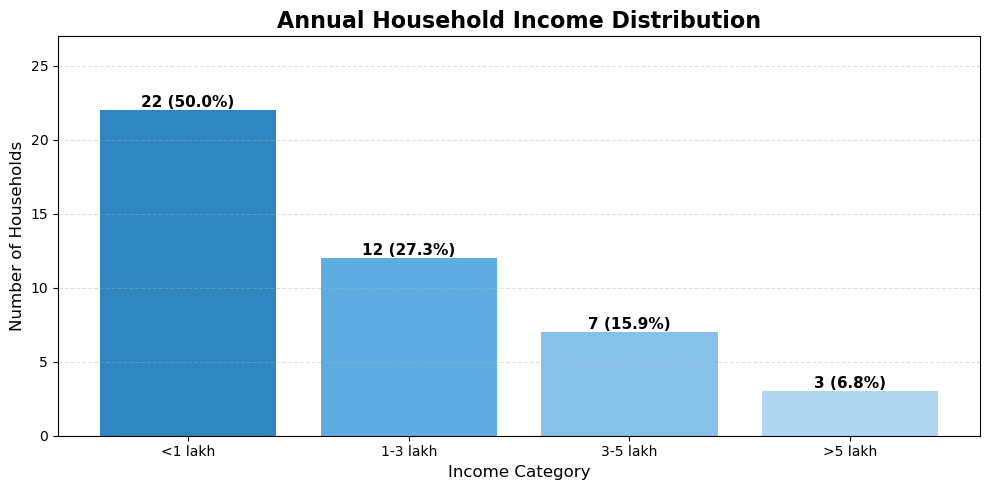

In [11]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
income_counts = df['Approx. Annual Household Income'].value_counts()
income_counts = income_counts[order]

plt.figure(figsize=(10,5))

colors = ['#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
bars = plt.bar(income_counts.index, income_counts.values, color=colors)

total = income_counts.sum()

for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

plt.title("Annual Household Income Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.ylim(0, income_counts.values.max()+5)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Occupational Diversity Indicator

In [12]:
occupation_dist = df['Main Occupation'].value_counts(normalize=True) * 100
occupation_dist = occupation_dist.round(2)
print(occupation_dist)

Main Occupation
Agriculture             43.18
Service                 31.82
Labour                  11.36
Business                 9.09
Agriculture, Service     4.55
Name: proportion, dtype: float64


In [13]:
df['Main Occupation'].value_counts()

Main Occupation
Agriculture             19
Service                 14
Labour                   5
Business                 4
Agriculture, Service     2
Name: count, dtype: int64

In [14]:
df['Approx. Annual Household Income'] = df['Approx. Annual Household Income'].str.strip()
df['Main Occupation'] = df['Main Occupation'].str.strip()

In [15]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
df['Approx. Annual Household Income'] = pd.Categorical(
    df['Approx. Annual Household Income'],
    categories=order,
    ordered=True)

income_occupation = pd.crosstab(
    df['Main Occupation'],
    df['Approx. Annual Household Income'])
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,9,8,2,0
"Agriculture, Service",1,1,0,0
Business,2,0,0,2
Labour,3,1,1,0
Service,7,2,4,1


In [16]:
occupations = df['Main Occupation'].value_counts().index
income_occupation = income_occupation.loc[occupations]
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,9,8,2,0
Service,7,2,4,1
Labour,3,1,1,0
Business,2,0,0,2
"Agriculture, Service",1,1,0,0


In [17]:
top_occupations = df['Main Occupation'].value_counts().head(5).index
income_occupation = income_occupation.loc[top_occupations]

In [18]:
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,9,8,2,0
Service,7,2,4,1
Labour,3,1,1,0
Business,2,0,0,2
"Agriculture, Service",1,1,0,0


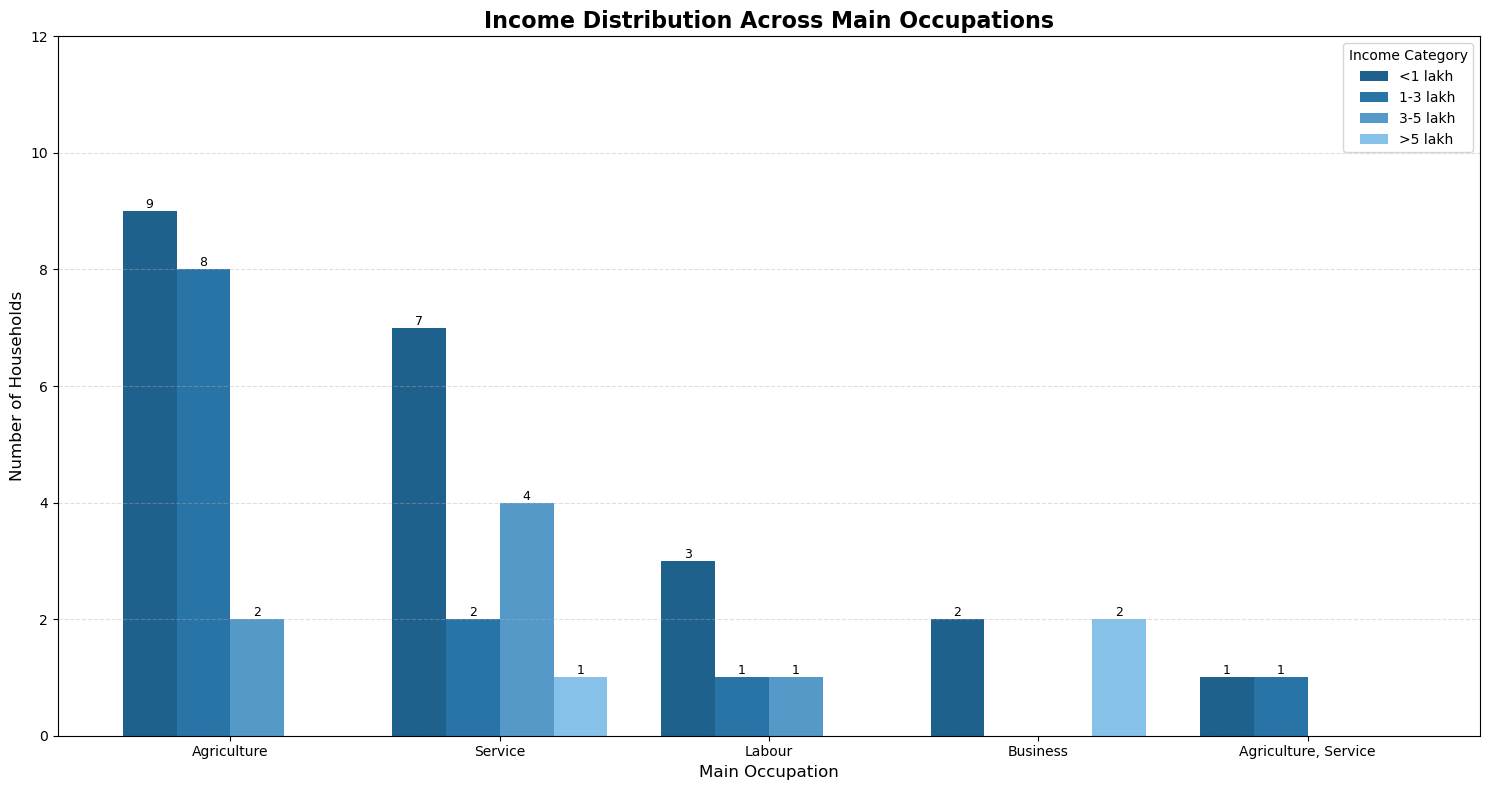

In [19]:
plt.figure(figsize=(15,8))

x = np.arange(len(income_occupation.index))
width = 0.2
colors = ['#1F618D', '#2874A6', '#5499C7', '#85C1E9']

for i, income_cat in enumerate(order):
    bars = plt.bar(x + i*width,
                   income_occupation[income_cat],
                   width,
                   label=income_cat,
                   color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2,
                     height,
                     int(height),
                     ha='center',
                     va='bottom',
                     fontsize=9)

plt.xticks(x + width*1.5, income_occupation.index)
plt.xlabel("Main Occupation", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.title("Income Distribution Across Main Occupations", fontsize=16, fontweight='bold')

plt.legend(title="Income Category")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, income_occupation.values.max()+3)
plt.tight_layout()
plt.show()

In [20]:
avg_family_size = df['Total Family Members'].mean()
print("Average Family Size:", round(avg_family_size,2))

Average Family Size: 6.23


# 3.Social Inclusion Profile

In [21]:
df['Social Category'].value_counts()

Social Category
General            26
OBC                10
Scheduled Caste     8
Name: count, dtype: int64

In [22]:
social_category = df['Social Category'].value_counts()
per_social_category = round((social_category/social_category.sum())*100,2)
per_social_category

Social Category
General            59.09
OBC                22.73
Scheduled Caste    18.18
Name: count, dtype: float64

In [23]:
round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [PM-KISAN]'], normalize='index') * 100,2)

Livelihood Schemes [PM-KISAN],Availed,Aware,Not Aware
Social Category,,,
General,7.69,11.54,80.77
OBC,0.00,30.00,70.00
Scheduled Caste,0.00,0.00,100.00


In [24]:
social = df['Social Category'].value_counts()
social = social.sort_values(ascending=False)
total = social.sum()

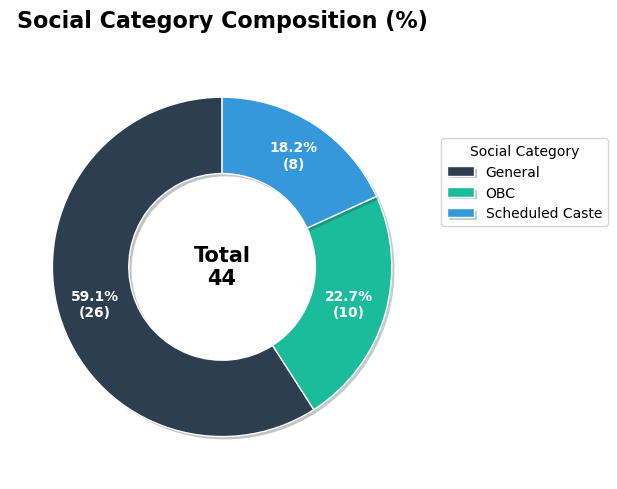

In [25]:
colors = ['#2C3E50', '#1ABC9C', '#3498DB', '#9B59B6']
plt.figure(figsize=(10,5))

wedges, texts, autotexts = plt.pie(social.values, startangle=90, colors=colors, wedgeprops=dict(width=0.45, edgecolor='white'),
                                   pctdistance=0.78, autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100))})")
for wedge in wedges:
    wedge.set_path_effects([
        pe.SimplePatchShadow(offset=(2, -2), alpha=0.25),
        pe.Normal()])

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.text(0, 0, f"Total\n{total}", ha='center', va='center', fontsize=15, fontweight='bold')
plt.title("Social Category Composition (%)", fontsize=16, fontweight='bold', pad=20)
plt.legend(wedges, social.index, title="Social Category", loc="center left", bbox_to_anchor=(1,0.7))
plt.tight_layout()
plt.show()

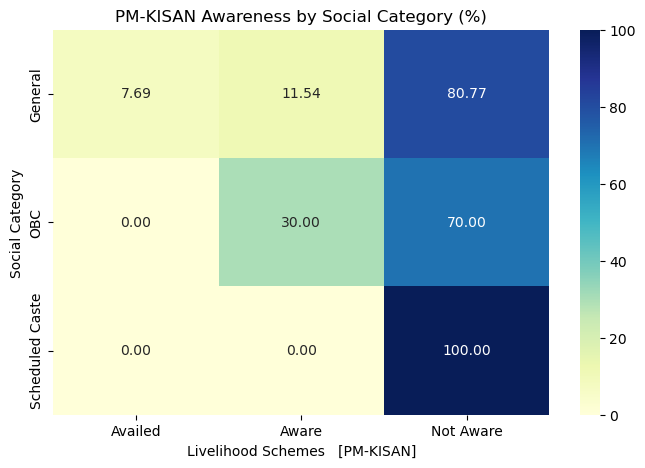

In [26]:
scheme_equity = pd.crosstab(
    df['Social Category'],
    df['Livelihood Schemes   [PM-KISAN]'],
    normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(scheme_equity,annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("PM-KISAN Awareness by Social Category (%)")
plt.show()

# Health & Nutrition Indicators Framework

# Institutional Delivery Rate

In [27]:
inst_delivery = df['Last delivery was institutional  (in any hospital)'].value_counts(normalize=True) * 100
round(inst_delivery,2)

Last delivery was institutional  (in any hospital)
YES    61.36
No     38.64
Name: proportion, dtype: float64

# Immunization Coverage (0–5 Years)

In [28]:
immunization = df['Immunization status of children (0-5)'].value_counts()
immunization

Immunization status of children (0-5)
Fully            25
Partially        11
Not immunised     8
Name: count, dtype: int64

In [29]:
immunization = df['Immunization status of children (0-5)'].value_counts(normalize=True) * 100
round(immunization,2)

Immunization status of children (0-5)
Fully            56.82
Partially        25.00
Not immunised    18.18
Name: proportion, dtype: float64

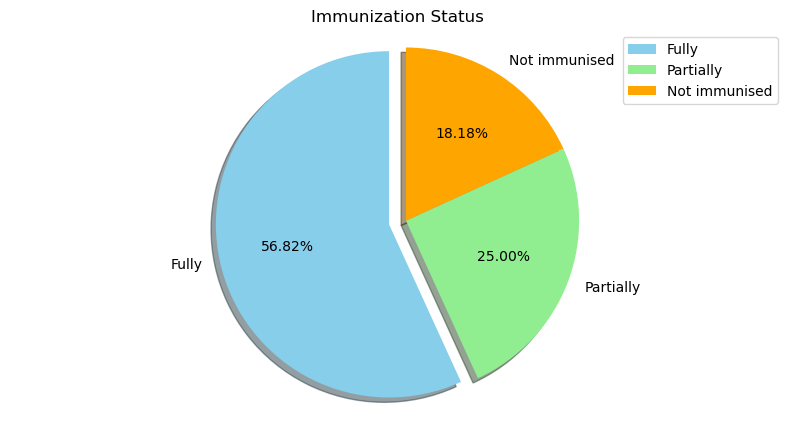

In [30]:
plt.figure(figsize=(10,5))
plt.pie(immunization.values, labels=immunization.index, autopct='%1.2f%%', startangle=90, explode = [0.1, 0, 0], shadow=True,
       colors=['skyblue','lightgreen','orange'])
plt.title("Immunization Status")
plt.axis('equal')
plt.legend()
plt.show()

# Healthcare Accessibility Gap

In [31]:
health_dist = df['Distance to nearest health facility'].value_counts()
health_dist

Distance to nearest health facility
1-5 km    25
>5 km     17
<1 km      2
Name: count, dtype: int64

In [32]:
health_dist = round(df['Distance to nearest health facility'].value_counts(normalize=True) * 100,2)
health_dist

Distance to nearest health facility
1-5 km    56.82
>5 km     38.64
<1 km      4.55
Name: proportion, dtype: float64

In [33]:
order = ['<1 km', '1-5 km', '>5 km']
health_dist = health_dist[order]

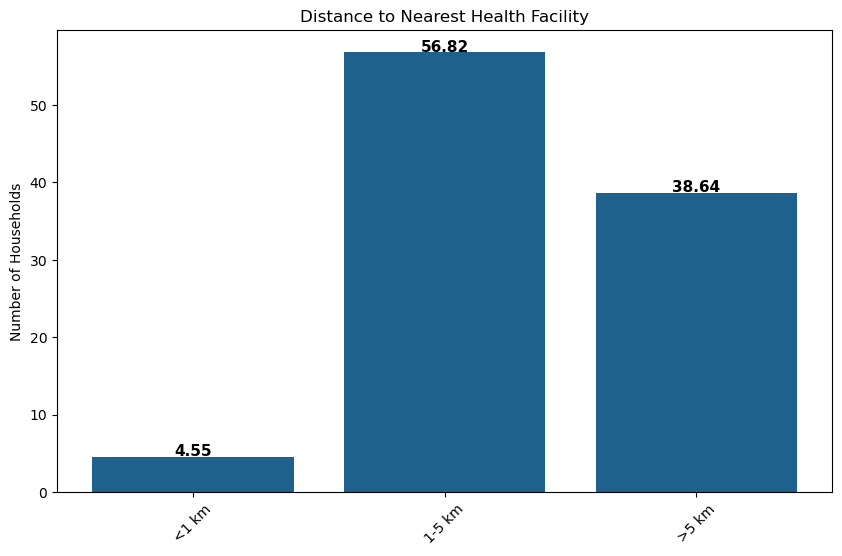

In [34]:
plt.figure(figsize=(10,6))
bars = plt.bar(health_dist.index, health_dist.values, color='#1F618D')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            bar.get_height(),
            ha='center',
            fontsize=11,
            fontweight='bold')
plt.title("Distance to Nearest Health Facility")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.show()

# Disease Prevalence Rate

In [35]:
df['Common diseases'].value_counts()

Common diseases
BP                 11
BP, Diabetes        7
Diabetes            4
BP, Respiratory     2
Name: count, dtype: int64

In [36]:
diseases_rate = df['Common diseases'].notna().mean() * 100
print(f'Diseases Rate = {round(diseases_rate,2)}%')

Diseases Rate = 54.55%


In [37]:
common_diseases = df['Common diseases'].str.split(',').explode().str.strip()

In [38]:
common_diseases_count = common_diseases.value_counts()
common_diseases_count

Common diseases
BP             20
Diabetes       11
Respiratory     2
Name: count, dtype: int64

In [39]:
common_diseases_percentage = round((common_diseases_count/common_diseases_count.sum())*100,2)
common_diseases_percentage

Common diseases
BP             60.61
Diabetes       33.33
Respiratory     6.06
Name: count, dtype: float64

# Scheme Awareness & Utilization (Health)

In [40]:
pmjay = round(df['Health Schemes   [Ayushman Bharat (PM-JAY)]'].value_counts(normalize=True) * 100,2)
pmjay

Health Schemes   [Ayushman Bharat (PM-JAY)]
Not aware    54.55
Applied      22.73
Aware        11.36
Availed      11.36
Name: proportion, dtype: float64

In [41]:
jsy = round(df['Health Schemes   [Janani Suraksha Yojana]'].value_counts(normalize=True) * 100,2)
jsy

Health Schemes   [Janani Suraksha Yojana]
Not aware    86.36
Applied       9.09
Aware         2.27
Availed       2.27
Name: proportion, dtype: float64

# Education & Digital Literacy Indicators

# 1. Household Literacy Rate

In [42]:
literacy = df['Literacy status of household'].value_counts()
literacy

Literacy status of household
All literate          20
Partially literate    15
Mostly illiterate      9
Name: count, dtype: int64

In [43]:
literacy_percent = round(df['Literacy status of household'].value_counts(normalize=True) * 100,2)
literacy_percent

Literacy status of household
All literate          45.45
Partially literate    34.09
Mostly illiterate     20.45
Name: proportion, dtype: float64

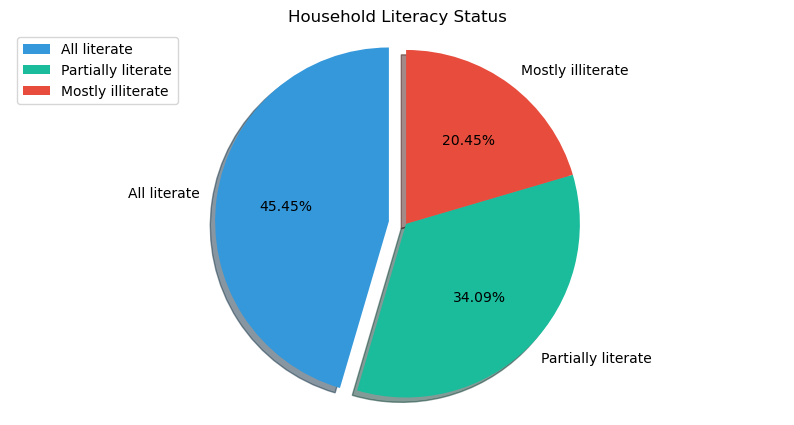

In [44]:
plt.figure(figsize=(10,5))
plt.pie(literacy_percent.values, labels=literacy_percent.index, autopct='%1.2f%%', startangle=90, colors=['#3498DB','#1ABC9C','#E74C3C'], shadow=True,
       explode=[0.1,0,0])
plt.title("Household Literacy Status")
plt.axis('equal')
plt.legend()
plt.show()

# 2. School Dropout Rate

In [45]:
dropout = df['School dropout cases  in the household'].value_counts()
dropout

School dropout cases  in the household
NO     37
YES     7
Name: count, dtype: int64

In [46]:
dropout_percent = round(df['School dropout cases  in the household'].value_counts(normalize=True) * 100,2)
dropout_percent

School dropout cases  in the household
NO     84.09
YES    15.91
Name: proportion, dtype: float64

In [47]:
reasons = df['Reason for dropout'].value_counts()
reasons

Reason for dropout
Lack of interest            4
Financial                   3
Domestic work               1
Migration                   1
Financial, Domestic work    1
Name: count, dtype: int64

In [48]:
reasons_percent = round(df['Reason for dropout'].value_counts(normalize=True)*100,2)
reasons_percent

Reason for dropout
Lack of interest            40.0
Financial                   30.0
Domestic work               10.0
Migration                   10.0
Financial, Domestic work    10.0
Name: proportion, dtype: float64

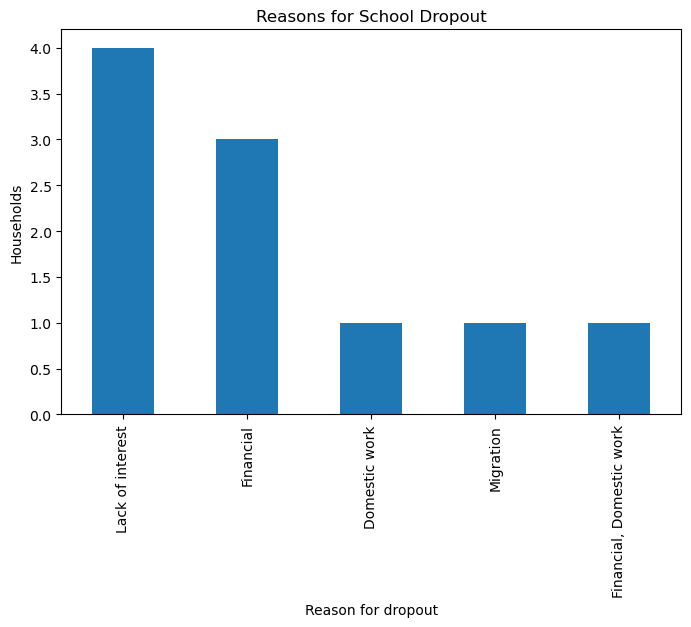

In [49]:
plt.figure(figsize=(8,5))
reasons.plot(kind='bar')
plt.title("Reasons for School Dropout")
plt.ylabel("Households")
plt.xticks(rotation=90)
plt.show()

In [50]:
reasons_strip = df['Reason for dropout'].str.split(',').explode().str.strip()

In [51]:
reasons_value = reasons_strip.value_counts()
reasons_value

Reason for dropout
Financial           4
Lack of interest    4
Domestic work       2
Migration           1
Name: count, dtype: int64

In [52]:
reasons_percentage = round((reasons_value/reasons_value.sum())*100,2)
reasons_percentage

Reason for dropout
Financial           36.36
Lack of interest    36.36
Domestic work       18.18
Migration            9.09
Name: count, dtype: float64

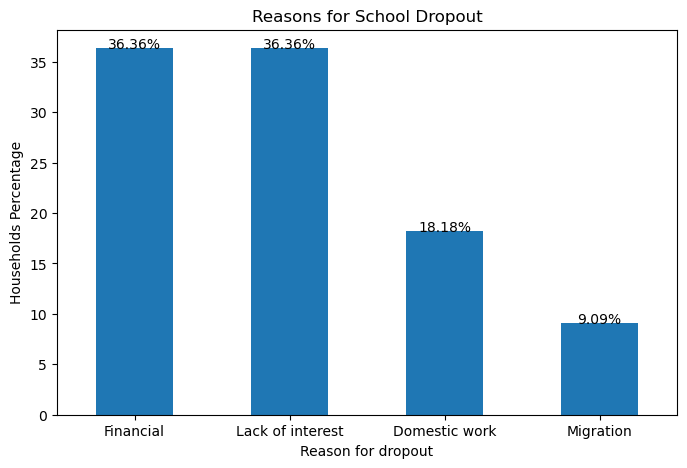

In [53]:
plt.figure(figsize=(8,5))
reasons_percentage.plot(kind='bar')
for i, v in enumerate(reasons_percentage.values):
    plt.text(i, v, f'{v:.2f}%', ha='center')
plt.title("Reasons for School Dropout")
plt.ylabel("Households Percentage")
plt.xticks(rotation=0)
plt.show()

# 3. Digital Divide Index

In [54]:
digital = df['Access to digital devices'].value_counts()
digital

Access to digital devices
Smartphone            32
Smartphone, Laptop    11
Laptop                 1
Name: count, dtype: int64

In [55]:
digital_percent = round(df['Access to digital devices'].value_counts(normalize=True) * 100,2)
digital_percent

Access to digital devices
Smartphone            72.73
Smartphone, Laptop    25.00
Laptop                 2.27
Name: proportion, dtype: float64

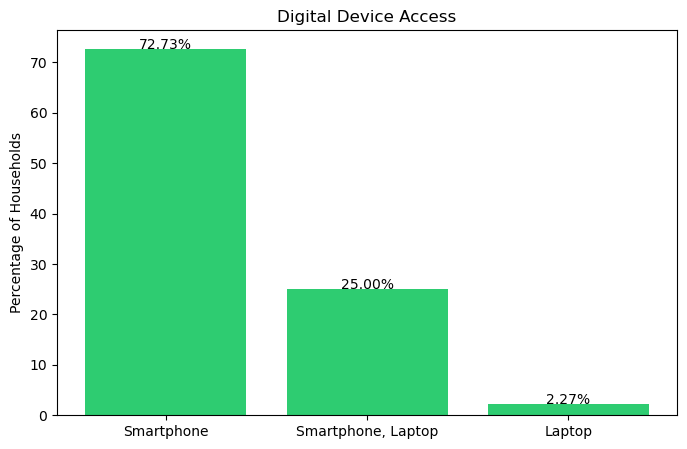

In [56]:
plt.figure(figsize=(8,5))
plt.bar(digital_percent.index, digital_percent.values, color='#2ECC71')
for i,v in enumerate(digital_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

In [57]:
digital_values = df['Access to digital devices'].str.split(',').explode().str.strip()

In [58]:
digital_count = digital_values.value_counts()
digital_count

Access to digital devices
Smartphone    43
Laptop        12
Name: count, dtype: int64

In [59]:
digital_percentage = round((digital_count/digital_count.sum())*100,2)
digital_percentage

Access to digital devices
Smartphone    78.18
Laptop        21.82
Name: count, dtype: float64

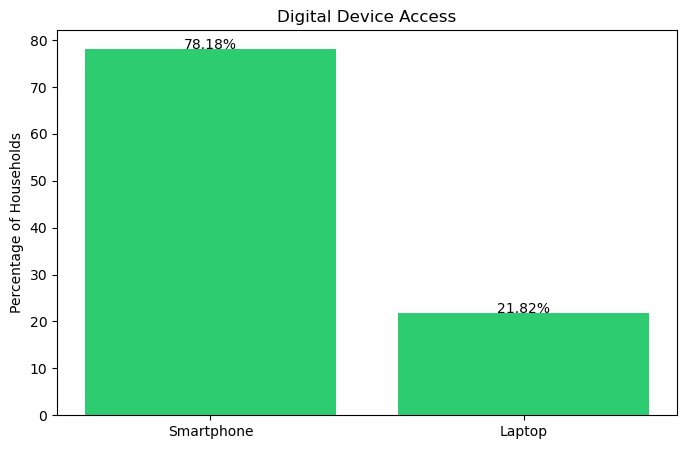

In [60]:
plt.figure(figsize=(8,5))
plt.bar(digital_percentage.index, digital_percentage.values, color='#2ECC71')
for i,v in enumerate(digital_percentage.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

# 4. Gender Gap in Higher Education

In [61]:
girls_edu = df['Girls continuing education beyond Class X'].value_counts()
girls_edu

Girls continuing education beyond Class X
YES    26
No     18
Name: count, dtype: int64

In [62]:
girls_edu_percent = round(df['Girls continuing education beyond Class X'].value_counts(normalize=True)*100,2)
girls_edu_percent

Girls continuing education beyond Class X
YES    59.09
No     40.91
Name: proportion, dtype: float64

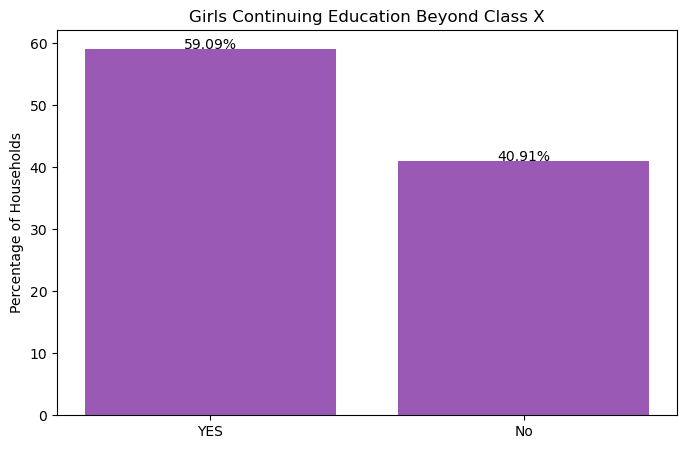

In [63]:
plt.figure(figsize=(8,5))
plt.bar(girls_edu_percent.index, girls_edu_percent.values, color='#9B59B6')

for i,v in enumerate(girls_edu_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Girls Continuing Education Beyond Class X")
plt.ylabel("Percentage of Households")
plt.show()

# 5. Remedial Support Demand

In [64]:
remedial = df['Need for remedial/coaching support'].value_counts()
remedial

Need for remedial/coaching support
No     27
Yes    17
Name: count, dtype: int64

In [65]:
remedial_percent = round(df['Need for remedial/coaching support'].value_counts(normalize=True)*100,2)
remedial_percent

Need for remedial/coaching support
No     61.36
Yes    38.64
Name: proportion, dtype: float64

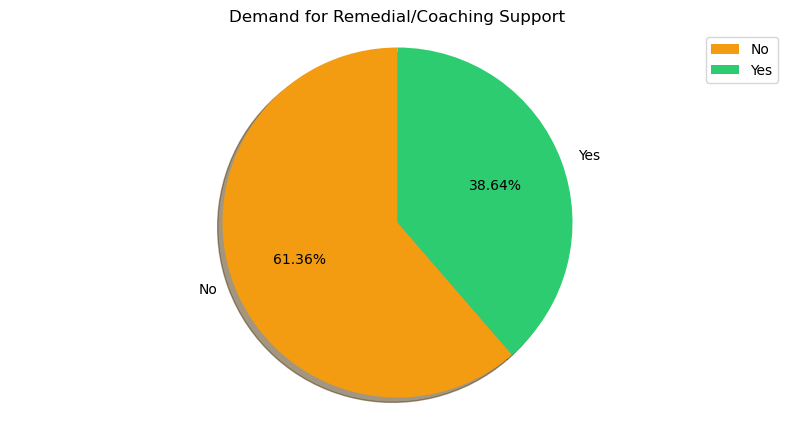

In [66]:
plt.figure(figsize=(10,5))
plt.pie(remedial_percent.values, labels=remedial_percent.index, autopct='%1.2f%%', colors=['#F39C12','#2ECC71'], startangle=90, shadow=True)
plt.title("Demand for Remedial/Coaching Support")
plt.axis('equal')
plt.legend()
plt.show()

# Water, Sanitation & Hygiene (WASH) Indicators

# 1. Safe Drinking Water Access

In [67]:
water_source = df['Source of drinking water'].value_counts()
water_source

Source of drinking water
Tap                       17
Tap, Tanker                7
Tap, Hand pump             6
Tanker                     5
Tap, Hand pump, Tanker     3
Hand pump                  3
Well                       2
Well, Tanker               1
Name: count, dtype: int64

In [68]:
water_source_split = df['Source of drinking water'].str.split(',').explode().str.strip()

In [69]:
water_source_count = water_source_split.value_counts()
water_source_count

Source of drinking water
Tap          33
Tanker       16
Hand pump    12
Well          3
Name: count, dtype: int64

In [70]:
water_source_percentage = round((water_source_count/water_source_count.sum())*100,2)
water_source_percentage

Source of drinking water
Tap          51.56
Tanker       25.00
Hand pump    18.75
Well          4.69
Name: count, dtype: float64

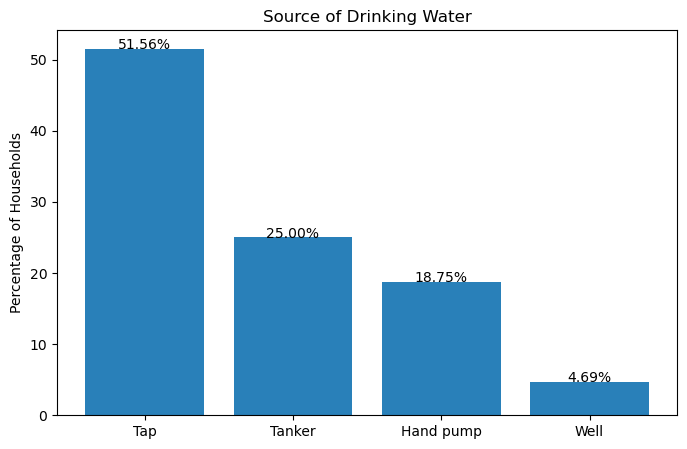

In [71]:
plt.figure(figsize=(8,5))
bars = plt.bar(water_source_percentage.index, water_source_percentage.values, color='#2980B9')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')

plt.title("Source of Drinking Water")
plt.ylabel("Percentage of Households")
plt.xticks()
plt.show()

In [72]:
water_quality = df['Quality of drinking water'].value_counts(normalize=True) * 100
round(water_quality,2)

Quality of drinking water
Good       79.55
Average    20.45
Name: proportion, dtype: float64

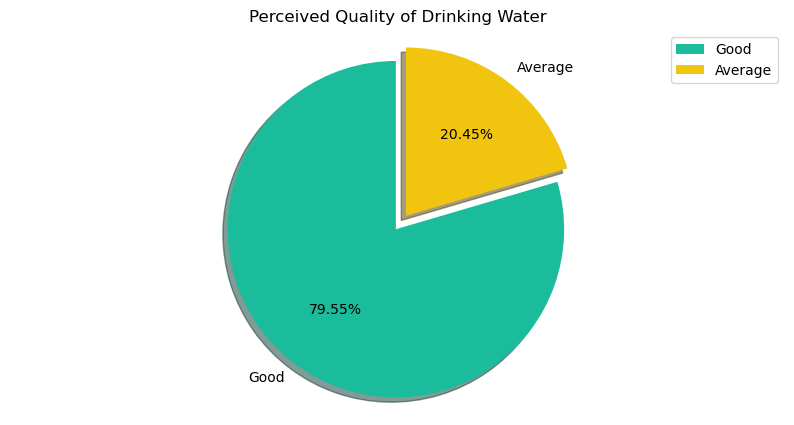

In [73]:
plt.figure(figsize=(10,5))
plt.pie(water_quality.values, labels=water_quality.index, autopct='%1.2f%%', explode=[0.1,0], colors=['#1ABC9C','#F1C40F','#E74C3C'], 
        startangle=90, shadow=True)
plt.title("Perceived Quality of Drinking Water")
plt.axis('equal')
plt.legend()
plt.show()

# 2. Sanitation Coverage

In [74]:
toilet = df['Toilet availability'].value_counts(normalize=True) * 100
round(toilet,2)

Toilet availability
YES    100.0
Name: proportion, dtype: float64

In [75]:
handwash = df['Handwashing with soap'].value_counts(normalize=True) * 100
round(handwash,2)

Handwashing with soap
Always       84.09
Sometimes    15.91
Name: proportion, dtype: float64

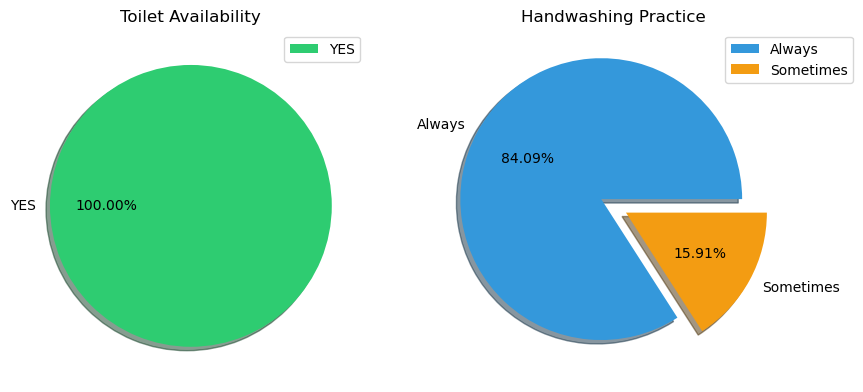

In [76]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.pie(toilet.values, labels=toilet.index, autopct='%1.2f%%',colors=['#2ECC71','#E74C3C'], shadow=True)
plt.title("Toilet Availability")
plt.legend()

plt.subplot(1,2,2)
plt.pie(handwash.values, labels=handwash.index, autopct='%1.2f%%',colors=['#3498DB','#F39C12','#E74C3C'], explode=[0.1,0.1], shadow=True)
plt.title("Handwashing Practice")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# 3. Waste Management Efficiency

In [77]:
waste = df['Solid waste disposal method'].value_counts()
waste

Solid waste disposal method
Open dumping             34
Open dumping, Burning     5
Door-to-door              4
Burning                   1
Name: count, dtype: int64

In [78]:
waste_percent = round(df['Solid waste disposal method'].value_counts(normalize=True)*100,2)
waste_percent

Solid waste disposal method
Open dumping             77.27
Open dumping, Burning    11.36
Door-to-door              9.09
Burning                   2.27
Name: proportion, dtype: float64

In [79]:
waste_split = df['Solid waste disposal method'].str.split(',').explode().str.strip()

In [80]:
waste_split_count = waste_split.value_counts()
waste_split_count

Solid waste disposal method
Open dumping    39
Burning          6
Door-to-door     4
Name: count, dtype: int64

In [81]:
waste_split_percentage = round((waste_split_count / waste_split_count.sum()) * 100, 2)
waste_split_percentage

Solid waste disposal method
Open dumping    79.59
Burning         12.24
Door-to-door     8.16
Name: count, dtype: float64

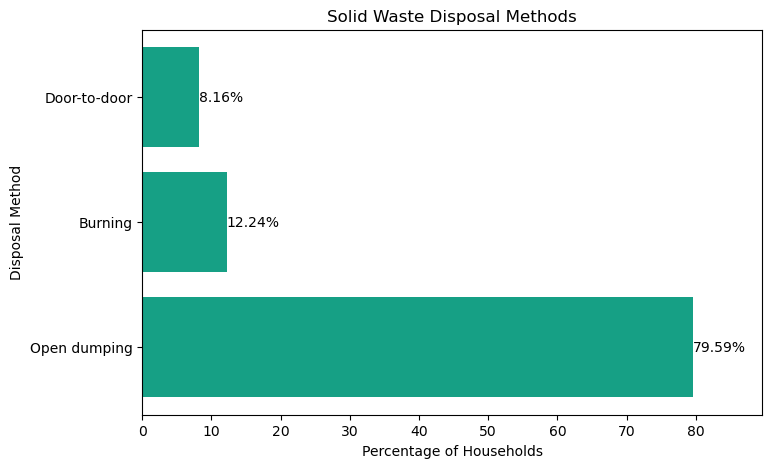

In [82]:
plt.figure(figsize=(8,5))
bars = plt.barh(waste_split_percentage.index, waste_split_percentage.values, color='#16A085')
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}%",
             va='center')

plt.title("Solid Waste Disposal Methods")
plt.xlabel("Percentage of Households")
plt.ylabel("Disposal Method")
plt.xlim(0,waste_split_percentage.values.max()+10)
plt.show()

# 4.Open Defecation Status

In [83]:
od = df['Open defecation in village'].value_counts(normalize=True) * 100
round(od,2)

Open defecation in village
No     56.82
Yes    43.18
Name: proportion, dtype: float64

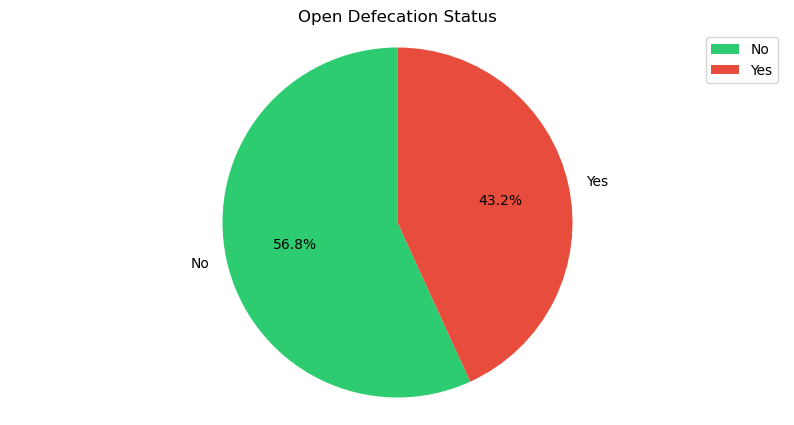

In [84]:
plt.figure(figsize=(10,5))
plt.pie(od.values, labels=od.index, autopct='%1.1f%%', colors=['#2ECC71','#E74C3C'], startangle=90)
plt.title("Open Defecation Status")
plt.axis('equal')
plt.legend()
plt.show()

# Environmental & Disaster Resilience Indicators

# 1. Environmental Stress Index

In [85]:
env_stress = df['Major environmental problems'].value_counts()
env_stress

Major environmental problems
Solid waste                                             27
Groundwater depletion                                    7
Flooding, Solid waste                                    4
Soil degradation                                         2
Crop residue burning                                     1
Crop residue burning, Soil degradation                   1
Soil degradation, Solid waste                            1
Groundwater depletion, Soil degradation, Solid waste     1
Name: count, dtype: int64

In [86]:
env_stress = df['Major environmental problems'].str.split(',').explode().str.strip()

In [87]:
env_stress_counts = env_stress.value_counts()
env_stress_counts

Major environmental problems
Solid waste              33
Groundwater depletion     8
Soil degradation          5
Flooding                  4
Crop residue burning      2
Name: count, dtype: int64

In [88]:
percentage_env_stress_counts = round(env_stress.value_counts(normalize=True)*100,2)
percentage_env_stress_counts

Major environmental problems
Solid waste              63.46
Groundwater depletion    15.38
Soil degradation          9.62
Flooding                  7.69
Crop residue burning      3.85
Name: proportion, dtype: float64

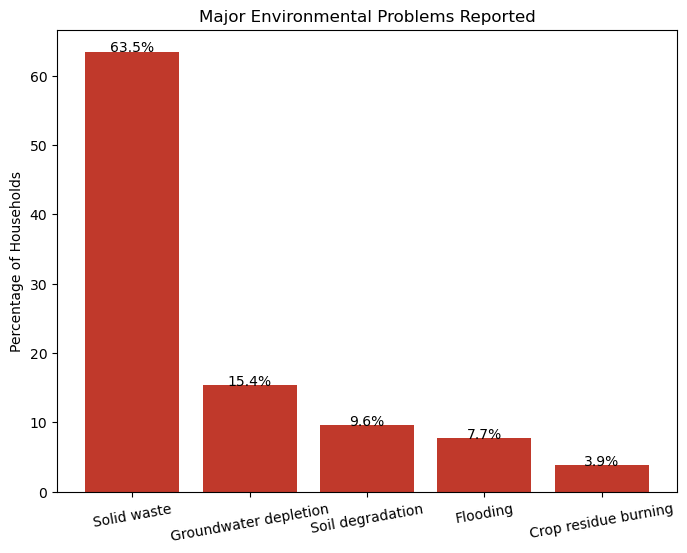

In [89]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_env_stress_counts.index, percentage_env_stress_counts.values, color='#C0392B')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Major Environmental Problems Reported")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=10)
plt.show()

# 2. Renewable Energy Adoption

In [90]:
#df['Renewable energy usage'].value_counts()

In [91]:
#renewable = df['Renewable energy usage'].str.split(',').explode().str.strip()

In [92]:
#renewable_counts = renewable.value_counts()
#renewable_counts

In [93]:
#percentage_renewable_counts = round(renewable.value_counts(normalize=True)*100,2)
#percentage_renewable_counts

In [94]:
#plt.figure(figsize=(10,5))
#plt.pie(percentage_renewable_counts.values, labels=percentage_renewable_counts.index, autopct='%1.1f%%', startangle=60, shadow = True,
#        colors=['#F1C40F','#27AE60','#95A5A6', '#C0392B'], explode=[0.1,0,0])
#plt.title("Renewable Energy Adoption")
#plt.legend(loc='upper right')
#plt.axis('equal')
#plt.show()

# 3. Disaster Vulnerability Score

In [95]:
df['Disaster vulnerability'].value_counts()

Disaster vulnerability
Flood             2
Heatwave          1
Heatwave, None    1
Name: count, dtype: int64

In [96]:
disaster = df['Disaster vulnerability'].str.split(',').explode().str.strip()

In [97]:
disaster_count = disaster.value_counts()
disaster_count

Disaster vulnerability
Heatwave    2
Flood       2
None        1
Name: count, dtype: int64

In [98]:
disaster_percent = round(disaster.value_counts(normalize=True)*100,2)
disaster_percent

Disaster vulnerability
Heatwave    40.0
Flood       40.0
None        20.0
Name: proportion, dtype: float64

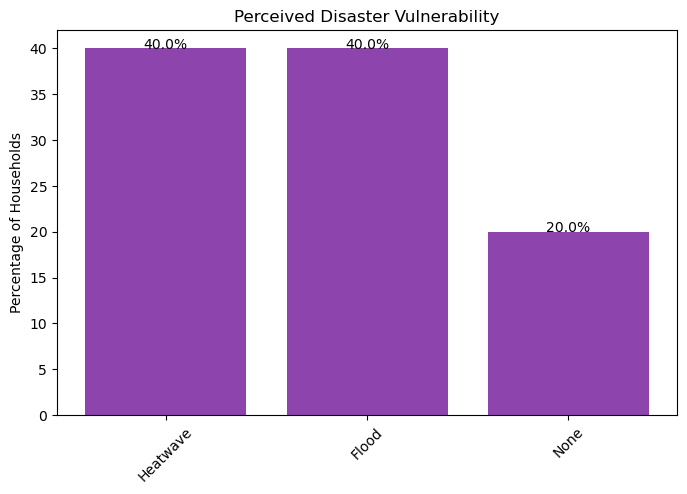

In [99]:
plt.figure(figsize=(8,5))
bars = plt.bar(disaster_percent.index, disaster_percent.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Perceived Disaster Vulnerability")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=45)
plt.show()

# 4. Pond Health Status

In [100]:
pond_condition = df['Condition of pond'].value_counts()
pond_condition

Condition of pond
Partially polluted    23
Highly polluted       20
Clean                  1
Name: count, dtype: int64

In [101]:
pond_percent = round(df['Condition of pond'].value_counts(normalize=True)*100,2)
pond_percent

Condition of pond
Partially polluted    52.27
Highly polluted       45.45
Clean                  2.27
Name: proportion, dtype: float64

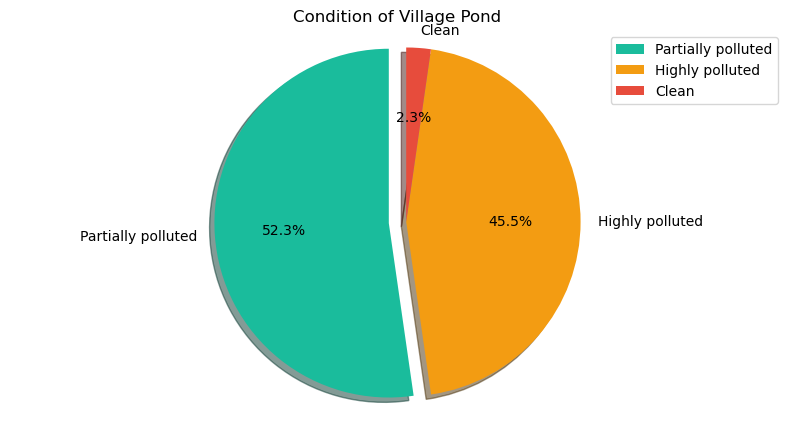

In [102]:
plt.figure(figsize=(10,5))
plt.pie(pond_percent.values, labels=pond_percent.index, autopct='%1.1f%%', colors=['#1ABC9C','#F39C12','#E74C3C'], startangle=90, explode=[0.1,0,0], 
       shadow=True)
plt.title("Condition of Village Pond")
plt.axis('equal')
plt.legend()
plt.show()

# Women Empowerment & Governance Indicators

# Female Labour Force Participation

In [103]:
female_lfp = df['Household women  engaged in income activity'].value_counts()
female_lfp

Household women  engaged in income activity
No     34
Yes    10
Name: count, dtype: int64

In [104]:
percentage_female_lfp = round(df['Household women  engaged in income activity'].value_counts(normalize=True)*100,2)
percentage_female_lfp

Household women  engaged in income activity
No     77.27
Yes    22.73
Name: proportion, dtype: float64

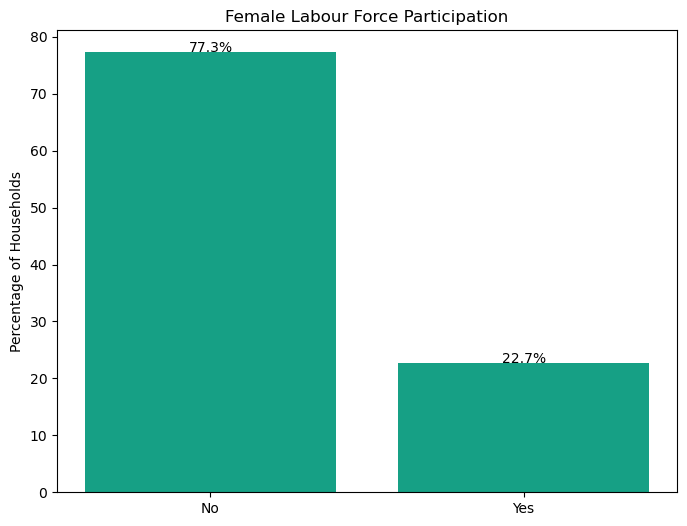

In [105]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_female_lfp.index, percentage_female_lfp.values, color='#16A085')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')

plt.title("Female Labour Force Participation")
plt.ylabel("Percentage of Households")
plt.show()

# Women Bank Account Ownership

In [106]:
women_bank = df['Bank account in woman’s name'].value_counts()
women_bank

Bank account in woman’s name
Yes    32
No     12
Name: count, dtype: int64

In [107]:
percentage_women_bank = round(df['Bank account in woman’s name'].value_counts(normalize=True)*100,2)
percentage_women_bank

Bank account in woman’s name
Yes    72.73
No     27.27
Name: proportion, dtype: float64

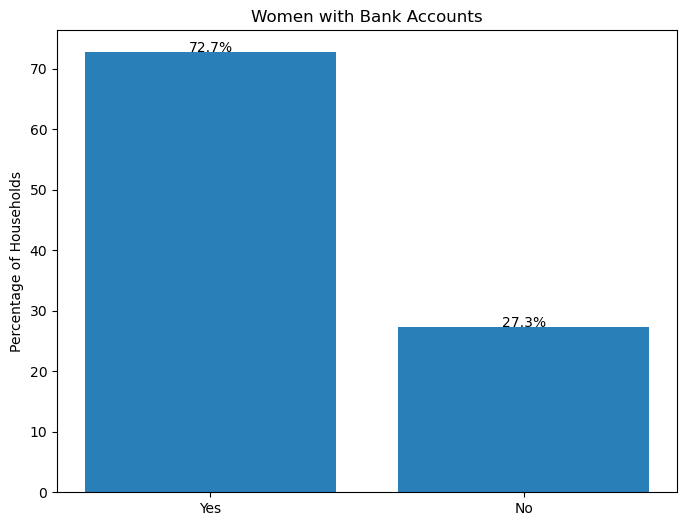

In [108]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_women_bank.index, percentage_women_bank.values, color='#2980B9')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women with Bank Accounts")
plt.ylabel("Percentage of Households")
plt.show()

# SHG Membership

In [109]:
shg = df['SHG membership'].value_counts()
shg

SHG membership
No     42
Yes     2
Name: count, dtype: int64

In [110]:
percentage_shg = round(df['SHG membership'].value_counts(normalize=True)*100,2)
percentage_shg

SHG membership
No     95.45
Yes     4.55
Name: proportion, dtype: float64

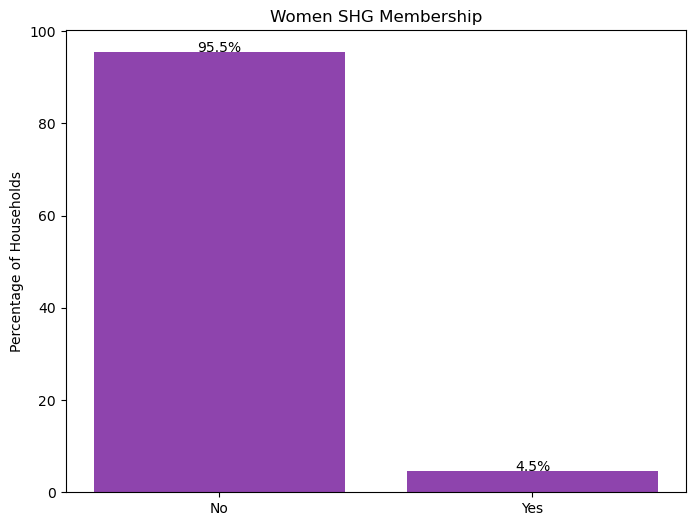

In [111]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_shg.index, percentage_shg.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women SHG Membership")
plt.ylabel("Percentage of Households")
plt.show()

# Governance Awareness (Gram Sabha)

In [112]:
gram_sabha = df['Awareness about Gram Sabha meetings'].value_counts()
gram_sabha

Awareness about Gram Sabha meetings
No     22
Yes    22
Name: count, dtype: int64

In [113]:
percentage_gram_sabha = round(df['Awareness about Gram Sabha meetings'].value_counts(normalize=True)*100,2)
percentage_gram_sabha

Awareness about Gram Sabha meetings
No     50.0
Yes    50.0
Name: proportion, dtype: float64

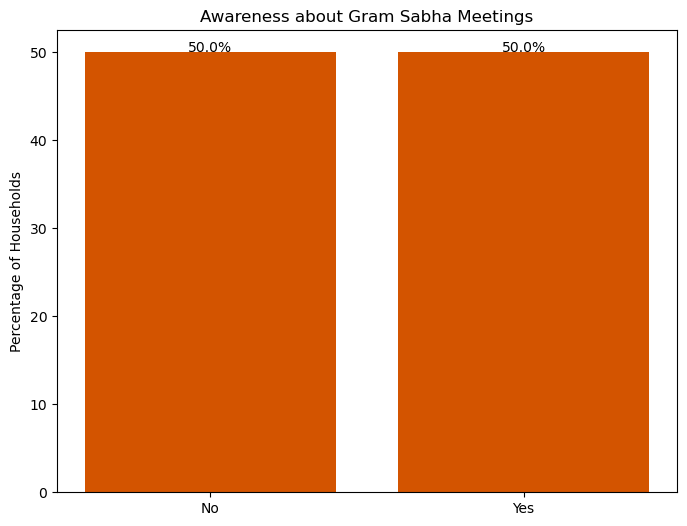

In [114]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_gram_sabha.index, percentage_gram_sabha.values, color='#D35400')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Awareness about Gram Sabha Meetings")
plt.ylabel("Percentage of Households")
plt.show()

# Women Decision-Making Power

In [115]:
decision = df['Role of women in decision-making'].value_counts()
decision

Role of women in decision-making
Moderate    29
High        12
Low          3
Name: count, dtype: int64

In [116]:
percentage_decision = round(df['Role of women in decision-making'].value_counts(normalize=True)*100,2)
percentage_decision

Role of women in decision-making
Moderate    65.91
High        27.27
Low          6.82
Name: proportion, dtype: float64

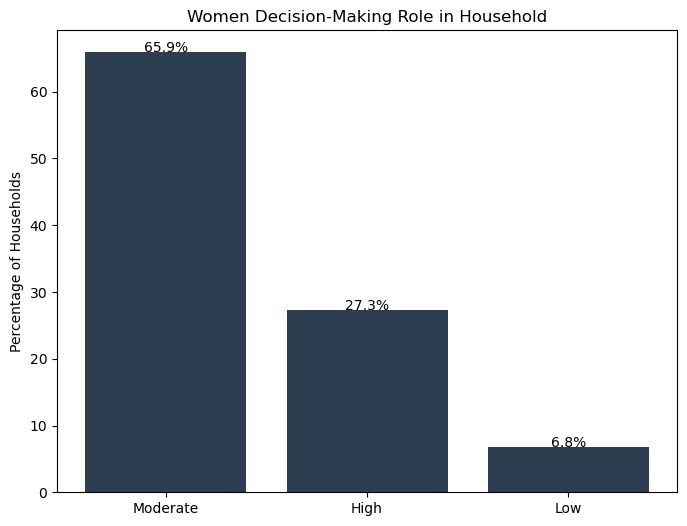

In [117]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_decision.index, percentage_decision.values, color='#2C3E50')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women Decision-Making Role in Household")
plt.ylabel("Percentage of Households")
plt.show()

# Strategie Gap Analysis (Qualitative to Quantitative)

# 1. Urgency Index (Most Urgent Village Needs)

In [118]:
print(df['Most urgent need of the village'])

0                                                   NaN
1                                 Road and electricity 
2                                         Road problems
3                                          Road issues 
4                            Drugs issue, road problems
5                                         Roads problem
6                                    Roads development 
7                                                   NaN
8                                    Water and severage
9                          Local roads are the problem 
10                                                  NaN
11                                    Coverage coverage
12                                    Roads Development
13          Health hospital related, waste management, 
14                                                  NaN
15                                            Hospital 
16                                          Dump clean 
17                                       Drainag

In [119]:
urgency = df['Most urgent need of the village'].value_counts()
urgency

Most urgent need of the village
Drainage                                                              2
Road and electricity                                                  1
Dumping area                                                          1
Eduction need, quailty of medicine and free treatment                 1
Dispensary                                                            1
Roads                                                                 1
Waste management                                                      1
Road and drainage                                                     1
Drugs issues, roads                                                   1
Garbage management, education till 12th class in government school    1
Road problems                                                         1
Road repairs                                                          1
Water and drainage system                                             1
Full fill the need of women empl

In [120]:
urgency.count()

np.int64(36)

In [121]:
urgency = df['Most urgent need of the village'].str.lower().str.strip()
urgency

0                                                   NaN
1                                  road and electricity
2                                         road problems
3                                           road issues
4                            drugs issue, road problems
5                                         roads problem
6                                     roads development
7                                                   NaN
8                                    water and severage
9                           local roads are the problem
10                                                  NaN
11                                    coverage coverage
12                                    roads development
13           health hospital related, waste management,
14                                                  NaN
15                                             hospital
16                                           dump clean
17                                       drainag

In [122]:
urgency_split = urgency.str.split(r'[,.]').explode().str.strip()
urgency_split

0                                                NaN
1                               road and electricity
2                                      road problems
3                                        road issues
4                                        drugs issue
4                                      road problems
5                                      roads problem
6                                  roads development
7                                                NaN
8                                 water and severage
9                        local roads are the problem
10                                               NaN
11                                 coverage coverage
12                                 roads development
13                           health hospital related
13                                  waste management
13                                                  
14                                               NaN
15                                          ho

In [123]:
urgency_split = urgency_split.replace('', pd.NA).dropna()
urgency_split

1                               road and electricity
2                                      road problems
3                                        road issues
4                                        drugs issue
4                                      road problems
5                                      roads problem
6                                  roads development
8                                 water and severage
9                        local roads are the problem
11                                 coverage coverage
12                                 roads development
13                           health hospital related
13                                  waste management
15                                          hospital
16                                        dump clean
17                                    drainage issue
18                                              road
19                                     road problems
19                              electricity pr

In [124]:
urgency_values = urgency_split.value_counts()
urgency_values.head(10)

Most urgent need of the village
road problems                                     3
garbage management                                2
drainage                                          2
roads development                                 2
roads                                             2
education related                                 2
health hospital related                           2
waste management                                  2
road and electricity                              1
education till 12th class in government school    1
Name: count, dtype: int64

In [125]:
category_map = {
    "hospital":"health",
    "hospitals":"health",
    "healthcare":"health",
    "health center":"health",
    "health facilities":"health",
    "medical":"health",
    "dispensary":"health",
    
    "roads":"roads",
    "road":"roads",
    "better roads":"roads",
    "road repair":"roads",
    "road development":"roads",
    "roads development":"roads",
    "good roads":"roads",
    
    "drainage":"sanitation",
    "drainage system":"sanitation",
    "sewage":"sanitation",
    "sewerage":"sanitation",
    "sewerage system":"sanitation",
    "sewage system":"sanitation",
    "severage":"sanitation",
    "waste management":"sanitation",
    "waste water treatment":"sanitation",
    
    "water":"water",
    "clean water":"water",
    "water supply":"water",
    "water management":"water",
    
    "school":"education",
    "education services":"education",
    
    "transport":"transport",
    "travelling":"transport",
    
    "cleaning":"cleanliness",
    "cleanliness":"cleanliness",
    "cleanness":"cleanliness"}

In [126]:
urgency_clean = urgency_split.replace(category_map)
urgency_summary = urgency_clean.value_counts()
urgency_summary.head(10)

Most urgent need of the village
roads                                             6
sanitation                                        5
road problems                                     3
education related                                 2
garbage management                                2
health                                            2
health hospital related                           2
road repairs                                      1
education till 12th class in government school    1
water and drainage system                         1
Name: count, dtype: int64

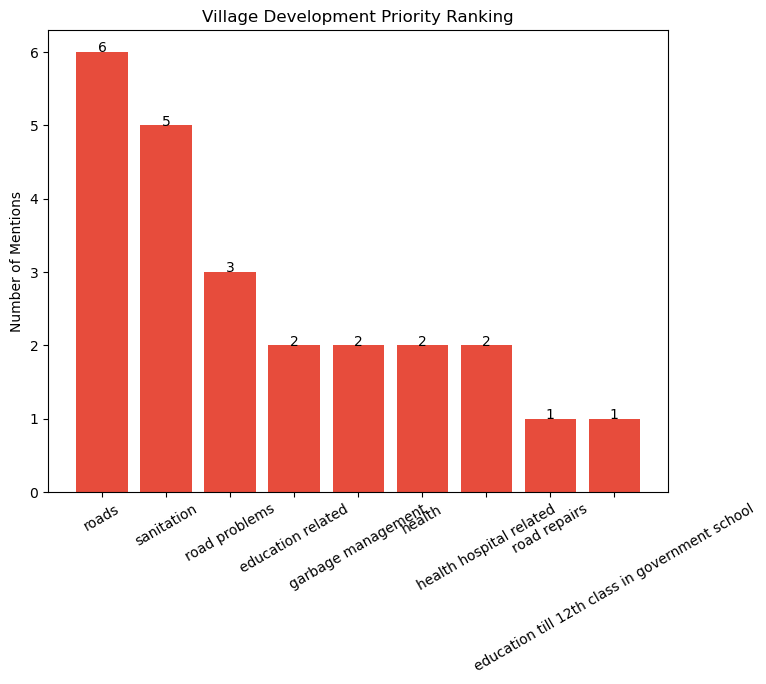

In [127]:
plt.figure(figsize=(8,6))
bars = plt.bar(urgency_summary.head(9).index, urgency_summary.head(9).values, color='#E74C3C')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()}",
             ha='center')
plt.title("Village Development Priority Ranking")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30)
plt.show()

# 2. Skill Gap Analysis

In [128]:
skill_trained = df['Skill-trained member in household'].value_counts()
skill_trained

Skill-trained member in household
Yes    28
No     16
Name: count, dtype: int64

In [129]:
percentage_skill_trained = round(df['Skill-trained member in household'].value_counts(normalize=True)*100,2)
percentage_skill_trained

Skill-trained member in household
Yes    63.64
No     36.36
Name: proportion, dtype: float64

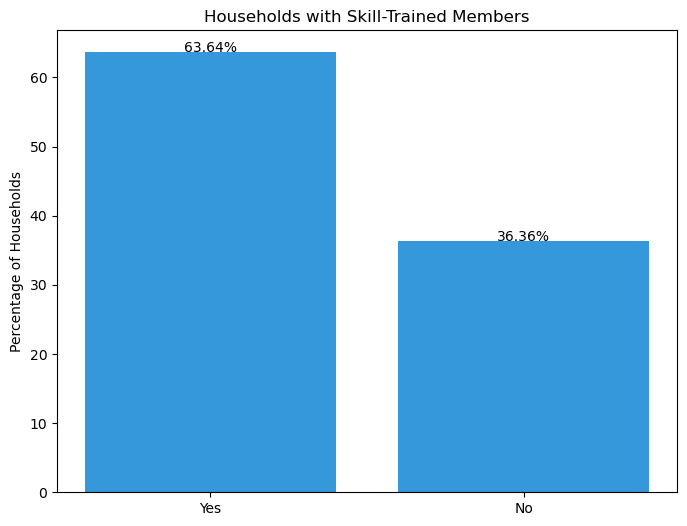

In [130]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skill_trained.index, percentage_skill_trained.values, color='#3498DB')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Households with Skill-Trained Members")
plt.ylabel("Percentage of Households")
plt.show()

In [131]:
df['Skills required'].value_counts()

Skills required
Agriculture                                  29
Driving                                       4
Computer                                      4
Agriculture, Tailoring, Computer, Driving     2
Electrical                                    2
Tailoring                                     1
Tailoring, Driving                            1
Electrical, Driving                           1
Name: count, dtype: int64

In [132]:
skills_required = df['Skills required'].str.split(',').explode().str.strip()

In [133]:
skills_required_counts = skills_required.value_counts()
skills_required_counts

Skills required
Agriculture    31
Driving         8
Computer        6
Tailoring       4
Electrical      3
Name: count, dtype: int64

In [134]:
percentage_skills_required = round(skills_required.value_counts(normalize=True)*100,2)
percentage_skills_required

Skills required
Agriculture    59.62
Driving        15.38
Computer       11.54
Tailoring       7.69
Electrical      5.77
Name: proportion, dtype: float64

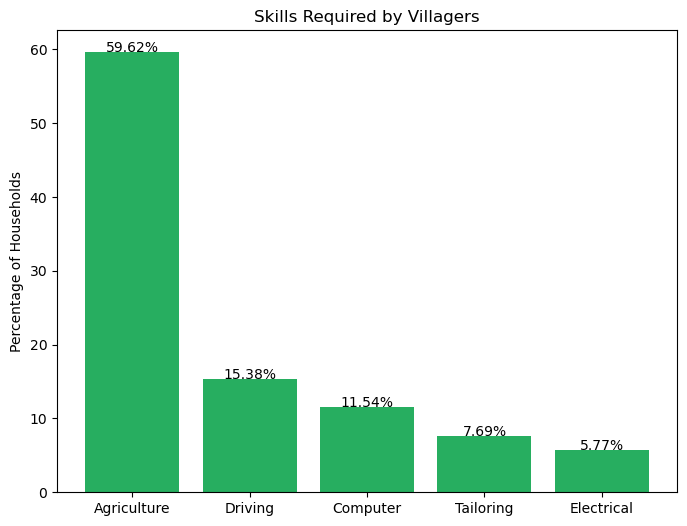

In [135]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skills_required.index, percentage_skills_required.values, color='#27AE60')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Skills Required by Villagers")
plt.ylabel("Percentage of Households")
plt.show()

# A. Poverty–Education–Migration Cycle Analysis

# 1. Income vs School Dropout (Poverty → Education)

In [136]:
income_dropout = pd.crosstab(df['Approx. Annual Household Income'], df['School dropout cases  in the household'], normalize='index') * 100
income_dropout

School dropout cases in the household,NO,YES
Approx. Annual Household Income,,
<1 lakh,86.363636,13.636364
1-3 lakh,75.000000,25.000000
3-5 lakh,85.714286,14.285714
>5 lakh,100.000000,0.000000


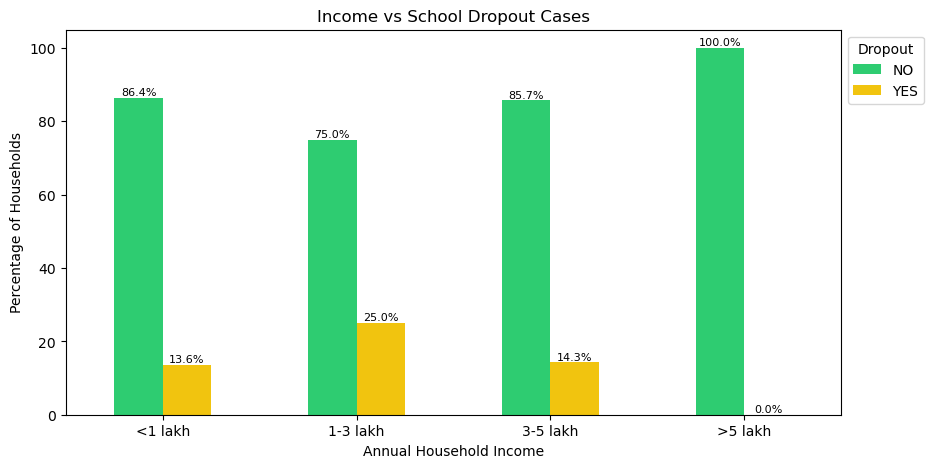

In [137]:
bars = income_dropout.plot(kind='bar', figsize=(10,5), color=['#2ECC71','#F1C40F','#E74C3C'])
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.1f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Income vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.xlabel("Annual Household Income")
plt.xticks(rotation=0)
plt.legend(title="Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Migration vs Reason for Dropout (Drivers)

In [138]:
migration_dropout_reason = round(pd.crosstab(df['Migration for employment'], df['Reason for dropout'], normalize='index') * 100,2)
migration_dropout_reason

Reason for dropout,Financial,"Financial, Domestic work",Lack of interest
Migration for employment,,,
Permanent,66.67,0.0,33.33
Seasonal,0.00,50.0,50.00


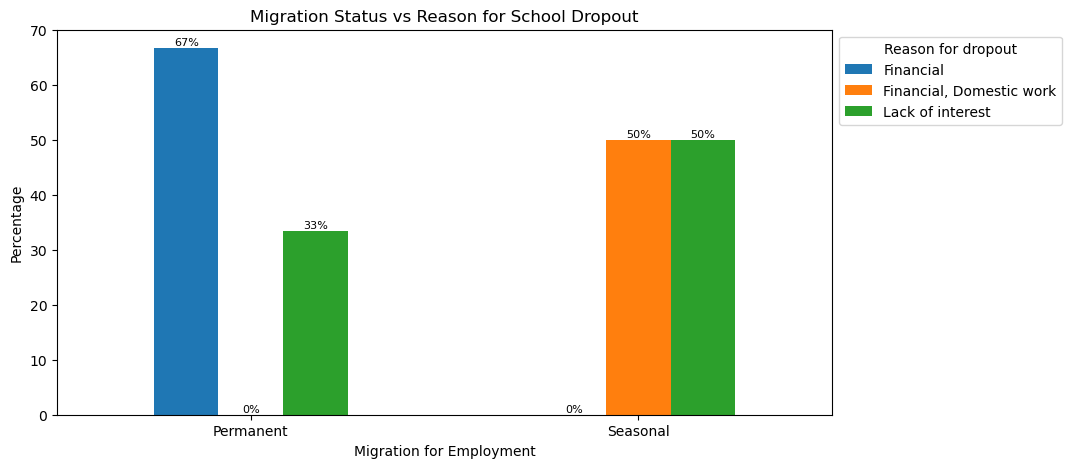

In [139]:
bars = migration_dropout_reason.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.0f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Migration Status vs Reason for School Dropout")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.xticks(rotation=0)
plt.legend(title="Reason for dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Literacy vs Migration (Outcome)

In [140]:
literacy_migration = round(pd.crosstab(df['Literacy status of household'], df['Migration for employment'], normalize='index') * 100,2)
literacy_migration

Migration for employment,Permanent,Seasonal
Literacy status of household,,
All literate,28.57,71.43
Mostly illiterate,50.00,50.00
Partially literate,33.33,66.67


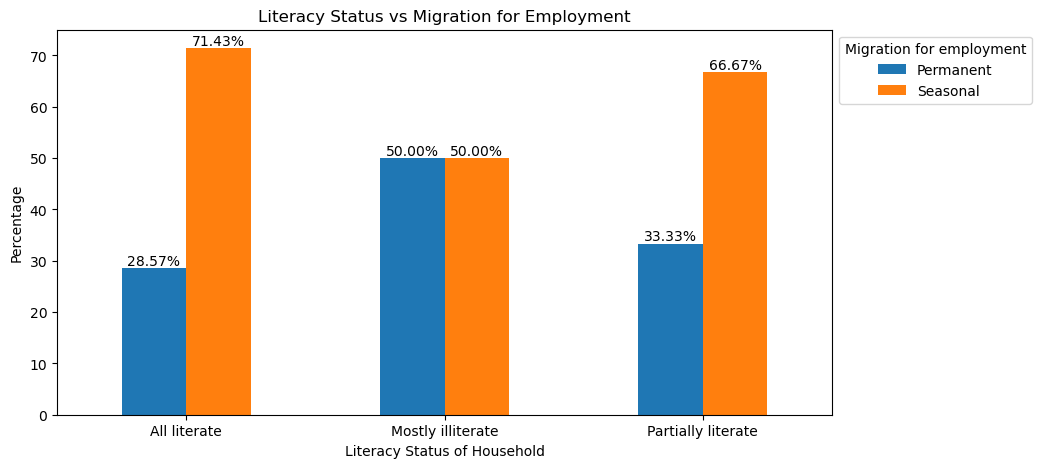

In [141]:
bars = literacy_migration.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}%',
             ha='center',
             va='bottom')
plt.title("Literacy Status vs Migration for Employment")
plt.ylabel("Percentage")
plt.xlabel("Literacy Status of Household")
plt.xticks(rotation=0)
plt.legend(title="Migration for employment", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [142]:
round(pd.crosstab([df['Approx. Annual Household Income'], df['Migration for employment']], df['School dropout cases  in the household'], 
            normalize='index') * 100, 2)

School dropout cases  in the household                       NO   YES
Approx. Annual Household Income Migration for employment             
<1 lakh                         Permanent                  50.0  50.0
                                Seasonal                  100.0   0.0
1-3 lakh                        Seasonal                  100.0   0.0
3-5 lakh                        Permanent                  50.0  50.0
                                Seasonal                  100.0   0.0
>5 lakh                         Permanent                 100.0   0.0
                                Seasonal                  100.0   0.0

# Social Equity in Public Service Delivery

# 1. Health Access Inequality

# Social Category vs Type of Health Facility Used

In [143]:
health_access = round(pd.crosstab(df['Social Category'], df['Type of facility used'], normalize='index') * 100,2)
health_access

Type of facility used,PHC,Private,Sub-Centre
Social Category,,,
General,3.85,76.92,19.23
OBC,0.00,100.00,0.00
Scheduled Caste,0.00,62.50,37.50


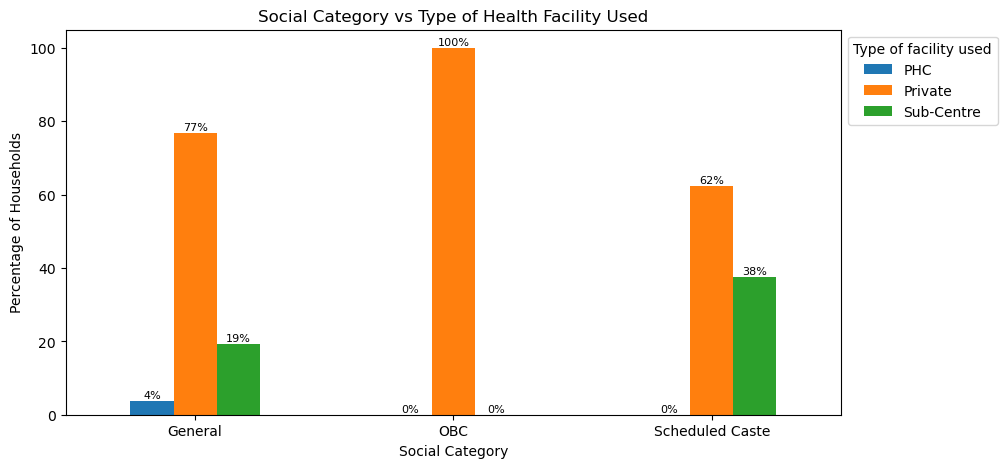

In [144]:
bars = health_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs Type of Health Facility Used")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs ASHA/ANM Visits

In [145]:
asha_visits = round(pd.crosstab(df['Social Category'], df['ASHA/ANM visit'], normalize='index') * 100, 2)
asha_visits

ASHA/ANM visit,Never,Occasional,Regular
Social Category,,,
General,26.92,57.69,15.38
OBC,20.00,80.00,0.00
Scheduled Caste,12.50,75.00,12.50


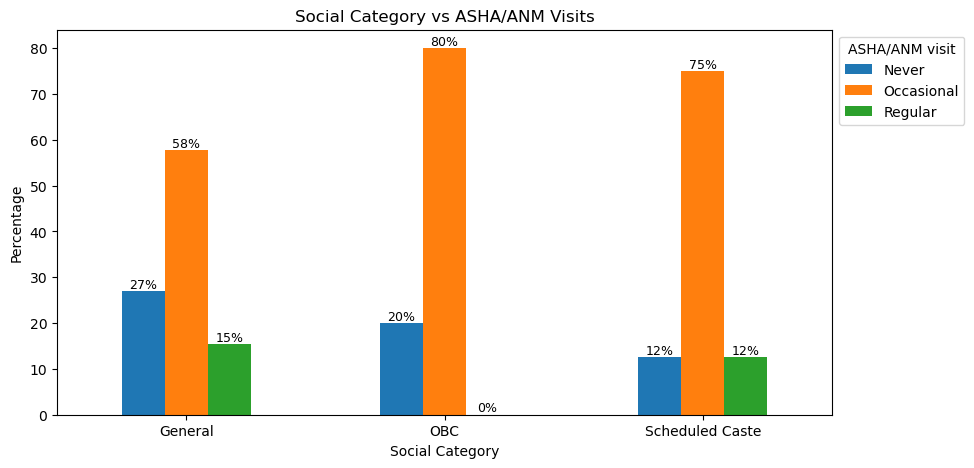

In [146]:
bars = asha_visits.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=9)
plt.title("Social Category vs ASHA/ANM Visits")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="ASHA/ANM visit", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Scheme Reach (Equity in Government Benefits)

# Social Category vs PM-JAY (Ayushman Bharat)

In [147]:
pmjay_access = round(pd.crosstab(df['Social Category'], df['Health Schemes   [Ayushman Bharat (PM-JAY)]'], normalize='index') * 100, 2)
pmjay_access

Health Schemes [Ayushman Bharat (PM-JAY)],Applied,Availed,Aware,Not aware
Social Category,,,,
General,26.92,15.38,3.85,53.85
OBC,10.00,10.00,40.00,40.00
Scheduled Caste,25.00,0.00,0.00,75.00


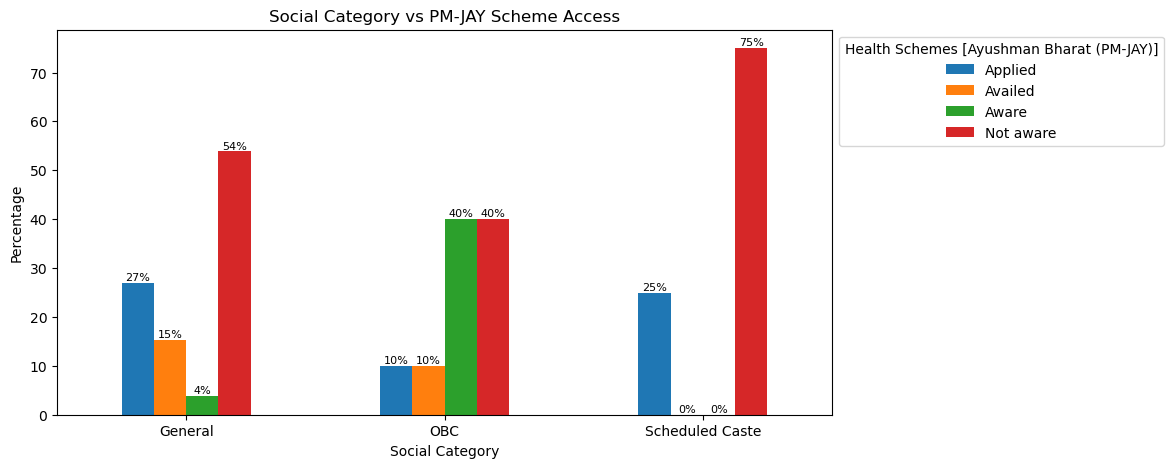

In [148]:
bars = pmjay_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs PM-JAY Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Health Schemes [Ayushman Bharat (PM-JAY)]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs MGNREGA

In [149]:
mgnrega_access = round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [MGNREGA]'], normalize='index') * 100, 2)
mgnrega_access

Livelihood Schemes [MGNREGA],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,3.85,7.69,15.38,73.08
OBC,0.00,0.00,90.00,10.00
Scheduled Caste,0.00,12.50,0.00,87.50


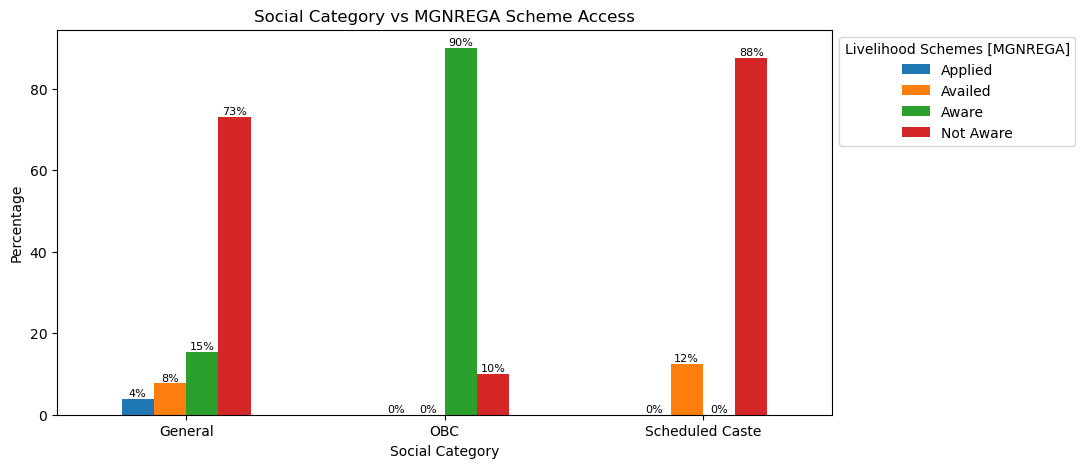

In [150]:
bars = mgnrega_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs MGNREGA Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Livelihood Schemes [MGNREGA]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Digital Divide Analysis

# Social Category vs Access to Digital Devices

In [151]:
digital_divide = round(pd.crosstab(df['Social Category'], df['Access to digital devices'], normalize='index') * 100, 2)
digital_divide

Access to digital devices,Laptop,Smartphone,"Smartphone, Laptop"
Social Category,,,
General,3.85,73.08,23.08
OBC,0.00,60.00,40.00
Scheduled Caste,0.00,87.50,12.50


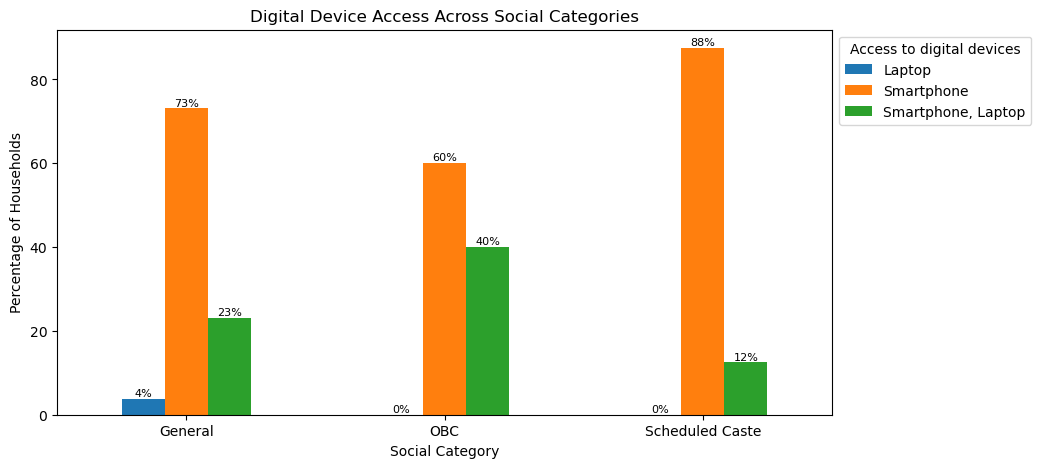

In [152]:
bars = digital_divide.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Digital Device Access Across Social Categories")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Access to digital devices", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Women's Economic Agency vs. Decision-Making Power

# 1. Income Activity vs Decision-Making Power

In [153]:
decision_income = round(pd.crosstab(df['Household women  engaged in income activity'], df['Role of women in decision-making'], normalize='index') 
                        * 100, 2)
decision_income

Role of women in decision-making,High,Low,Moderate
Household women engaged in income activity,,,
No,26.47,8.82,64.71
Yes,30.00,0.00,70.00


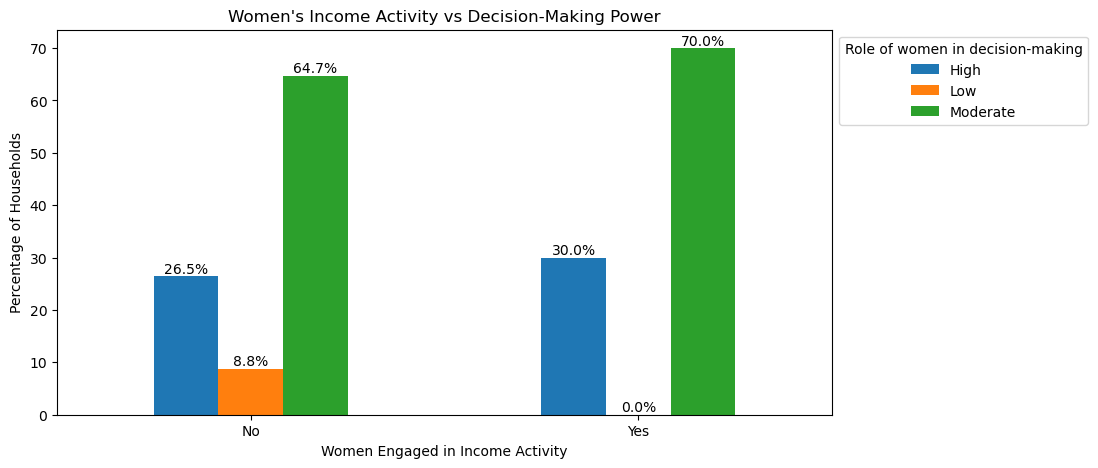

In [154]:
bars = decision_income.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Women's Income Activity vs Decision-Making Power")
plt.ylabel("Percentage of Households")
plt.xlabel("Women Engaged in Income Activity")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. SHG Membership vs Decision-Making Power

In [155]:
shg_decision = round(pd.crosstab(df['SHG membership'], df['Role of women in decision-making'], normalize='index') * 100, 2)
shg_decision

Role of women in decision-making,High,Low,Moderate
SHG membership,,,
No,26.19,7.14,66.67
Yes,50.00,0.00,50.00


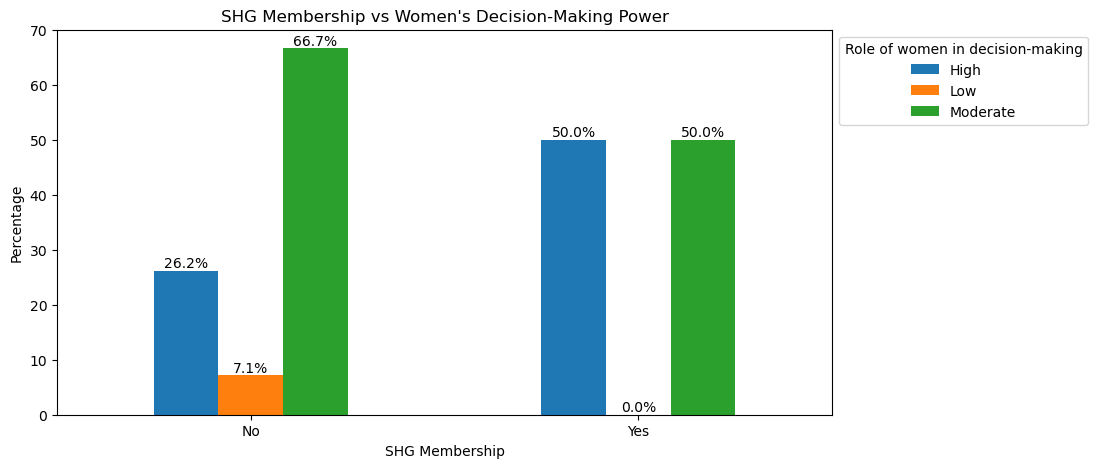

In [156]:
bars = shg_decision.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("SHG Membership vs Women's Decision-Making Power")
plt.ylabel("Percentage")
plt.xlabel("SHG Membership")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. SHG Membership vs Awareness of Women Schemes

In [157]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [NRLM]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [NRLM],Aware,Not Aware
SHG membership,,
No,2.38,97.62
Yes,0.00,100.00


In [158]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Pradhan Mantri Matru Vandana Yojana]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Pradhan Mantri Matru Vandana Yojana],Aware,Not Aware
SHG membership,,
No,4.76,95.24
Yes,0.00,100.00


In [159]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Beti Bachao Beti Padhao]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Beti Bachao Beti Padhao],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,0.0,2.38,33.33,64.29
Yes,50.0,0.00,50.00,0.00


In [160]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Sukanya Samriddhi]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Sukanya Samriddhi],Availed,Aware,Not Aware
SHG membership,,,
No,2.38,4.76,92.86
Yes,0.00,0.00,100.00


# Health Outcomes and Environmental Sanitation

# 1. Environmental Link

In [161]:
pond_disease = round(pd.crosstab( df['Condition of pond'], df['Common diseases'], normalize='index') * 100,2)
pond_disease

Common diseases,BP,"BP, Diabetes","BP, Respiratory",Diabetes
Condition of pond,,,,
Clean,100.00,0.00,0.00,0.00
Highly polluted,45.45,36.36,9.09,9.09
Partially polluted,41.67,25.00,8.33,25.00


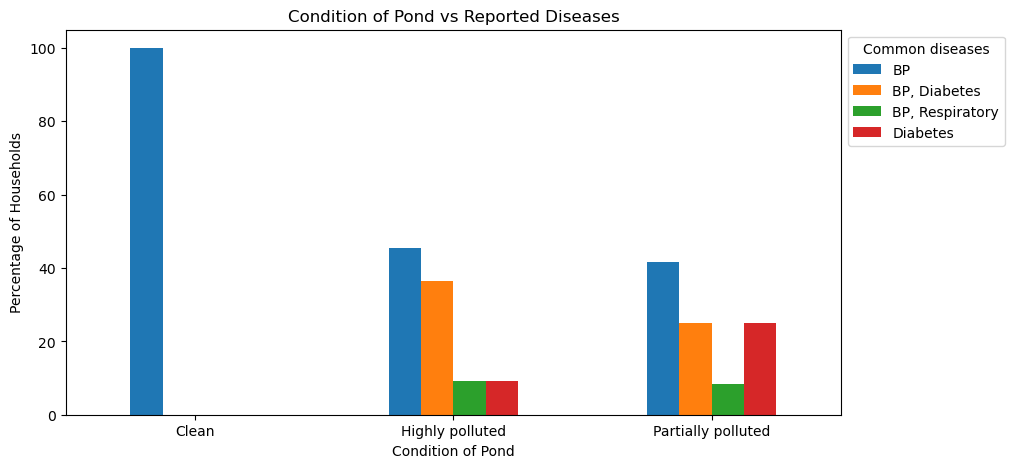

In [162]:
pond_disease.plot(kind='bar', figsize=(10,5))
plt.title("Condition of Pond vs Reported Diseases")
plt.ylabel("Percentage of Households")
plt.xlabel("Condition of Pond")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Solid Waste Disposal vs Diseases

In [163]:
waste_disease = round(pd.crosstab(df['Solid waste disposal method'], df['Common diseases'], normalize='index') * 100, 2)
waste_disease

Common diseases,BP,"BP, Diabetes","BP, Respiratory",Diabetes
Solid waste disposal method,,,,
Burning,100.00,0.0,0.0,0.00
Door-to-door,66.67,0.0,0.0,33.33
Open dumping,40.00,35.0,10.0,15.00


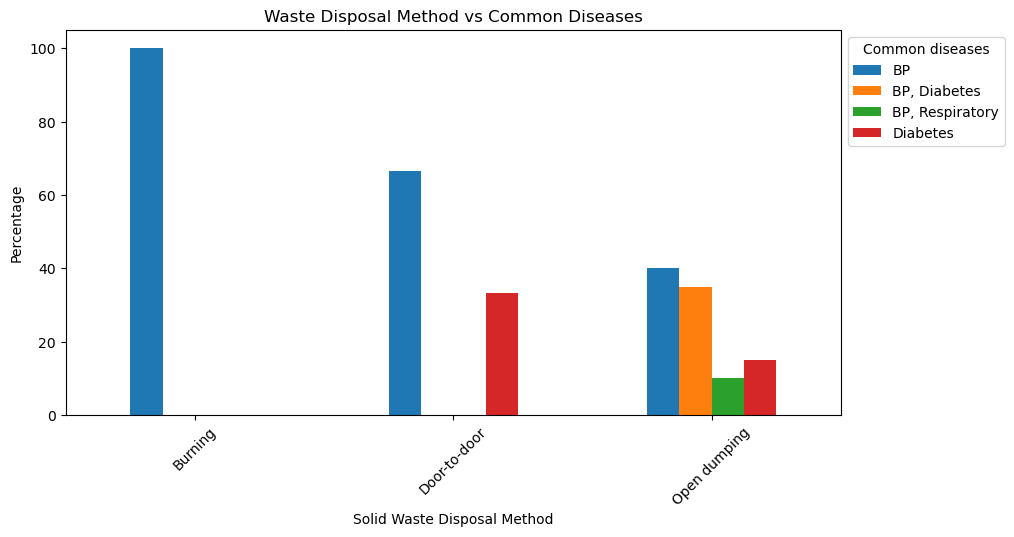

In [164]:
waste_disease.plot(kind='bar', figsize=(10,5))
plt.title("Waste Disposal Method vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Solid Waste Disposal Method")
plt.xticks(rotation=45)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Hygiene Practices vs Diseases

In [165]:
handwash_disease = round(pd.crosstab(df['Handwashing with soap'], df['Common diseases'], normalize='index') * 100, 2)
handwash_disease

Common diseases,BP,"BP, Diabetes","BP, Respiratory",Diabetes
Handwashing with soap,,,,
Always,45.0,25.0,10.0,20.0
Sometimes,50.0,50.0,0.0,0.0


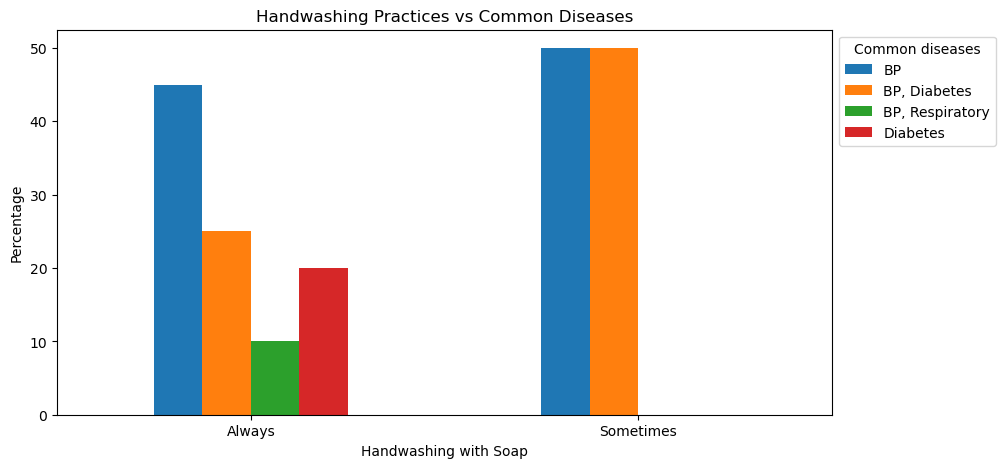

In [166]:
handwash_disease.plot(kind='bar', figsize=(10,5))
plt.title("Handwashing Practices vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Handwashing with Soap")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [167]:
toilet_disease = round(pd.crosstab(df['Toilet availability'], df['Common diseases'], normalize='index') * 100, 2)
toilet_disease

Common diseases,BP,"BP, Diabetes","BP, Respiratory",Diabetes
Toilet availability,,,,
YES,45.83,29.17,8.33,16.67


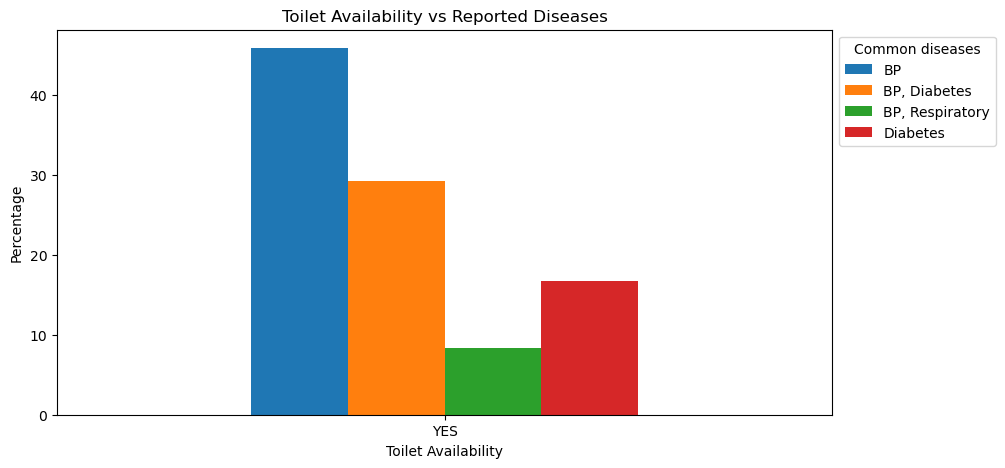

In [168]:
toilet_disease.plot(kind='bar', figsize=(10,5))
plt.title("Toilet Availability vs Reported Diseases")
plt.ylabel("Percentage")
plt.xlabel("Toilet Availability")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Infrastructure Accessibility & Service Utilization

# 1. Distance to Health Facility vs Immunization Status

In [169]:
health_distance_immunization = round(pd.crosstab(df['Distance to nearest health facility'], df['Immunization status of children (0-5)'], 
                                                 normalize='index') * 100, 2)
health_distance_immunization

Immunization status of children (0-5),Fully,Not immunised,Partially
Distance to nearest health facility,,,
1-5 km,48.00,16.00,36.00
<1 km,50.00,0.00,50.00
>5 km,70.59,23.53,5.88


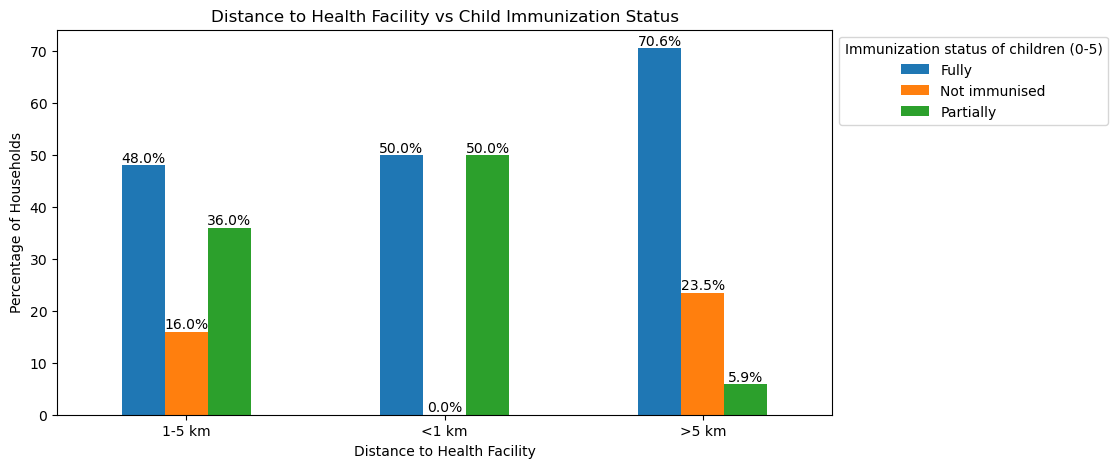

In [170]:
bars = health_distance_immunization.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Child Immunization Status")
plt.ylabel("Percentage of Households")
plt.xlabel("Distance to Health Facility")
plt.legend(title='Immunization status of children (0-5)', bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Distance to School vs Girls' Education

In [171]:
school_distance_girls = round(pd.crosstab(df['Distance to nearest school'], df['Girls continuing education beyond Class X'], normalize='index') 
                              * 100, 2)
school_distance_girls

Girls continuing education beyond Class X,No,YES
Distance to nearest school,,
1-3 km,37.50,62.50
<1 km,27.27,72.73
>3 km,64.29,35.71


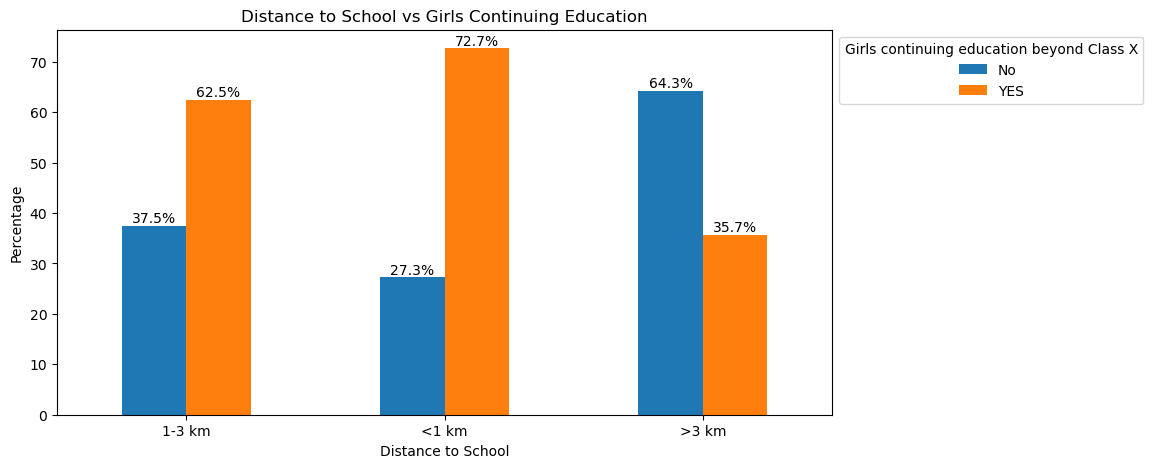

In [172]:
bars = school_distance_girls.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to School vs Girls Continuing Education")
plt.ylabel("Percentage")
plt.xlabel("Distance to School")
plt.legend(title="Girls continuing education beyond Class X", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Behavioral Shift in Healthcare Choice

In [173]:
distance_facility_type = round(pd.crosstab(df['Distance to nearest health facility'], df['Type of facility used'], normalize='index') * 100, 2)
distance_facility_type

Type of facility used,PHC,Private,Sub-Centre
Distance to nearest health facility,,,
1-5 km,4.0,76.00,20.00
<1 km,0.0,50.00,50.00
>5 km,0.0,88.24,11.76


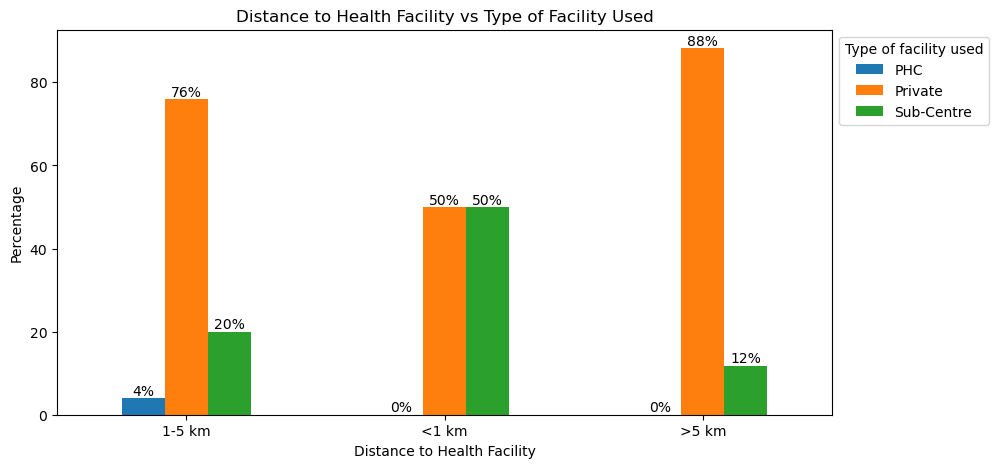

In [174]:
bars = distance_facility_type.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Type of Facility Used")
plt.ylabel("Percentage")
plt.xlabel("Distance to Health Facility")
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Village Governance & Civic Engagement

# 1. Knowledge–Action Gap

In [175]:
awareness_participation = round(pd.crosstab(df['Awareness about Gram Sabha meetings'], df['Participation in village development'], normalize='index')
                                * 100, 2)
awareness_participation

Participation in village development,Never,Occasional,Regular
Awareness about Gram Sabha meetings,,,
No,45.45,45.45,9.09
Yes,22.73,40.91,36.36


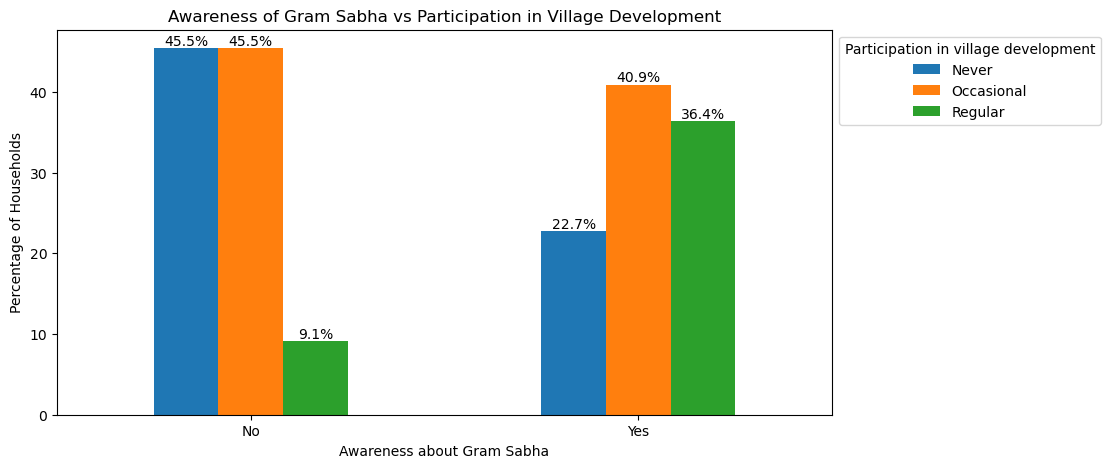

In [176]:
bars = awareness_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Awareness of Gram Sabha vs Participation in Village Development")
plt.ylabel("Percentage of Households")
plt.xlabel("Awareness about Gram Sabha")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Migration vs Participation

In [177]:
migration_participation = round(pd.crosstab(df['Migration for employment'], df['Participation in village development'], normalize='index') * 100, 2)
migration_participation

Participation in village development,Never,Occasional,Regular
Migration for employment,,,
Permanent,60.0,40.0,0.0
Seasonal,20.0,30.0,50.0


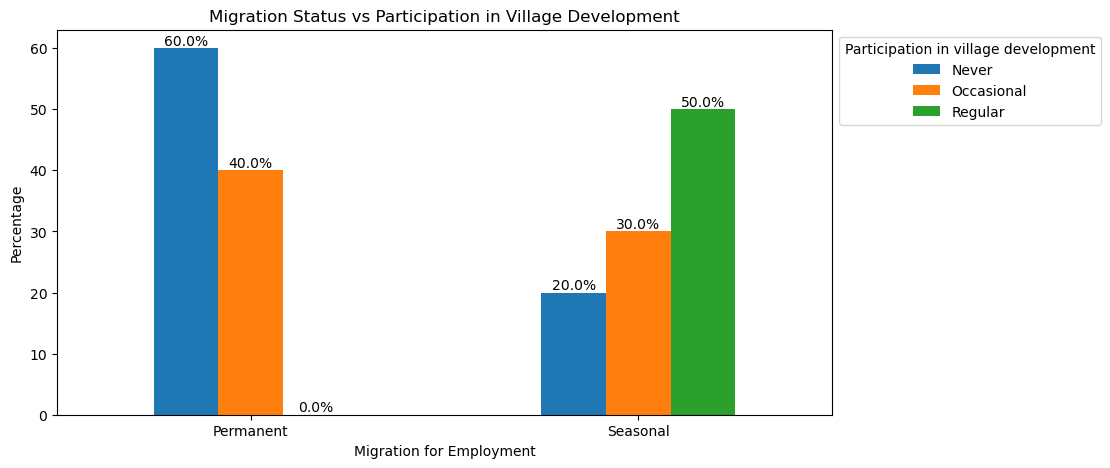

In [178]:
bars = migration_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Migration Status vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Social Category vs Participation (Inclusion)

In [179]:
social_participation = round(pd.crosstab(df['Social Category'], df['Participation in village development'], normalize='index') * 100, 2)
social_participation

Participation in village development,Never,Occasional,Regular
Social Category,,,
General,30.77,38.46,30.77
OBC,40.00,40.00,20.00
Scheduled Caste,37.50,62.50,0.00


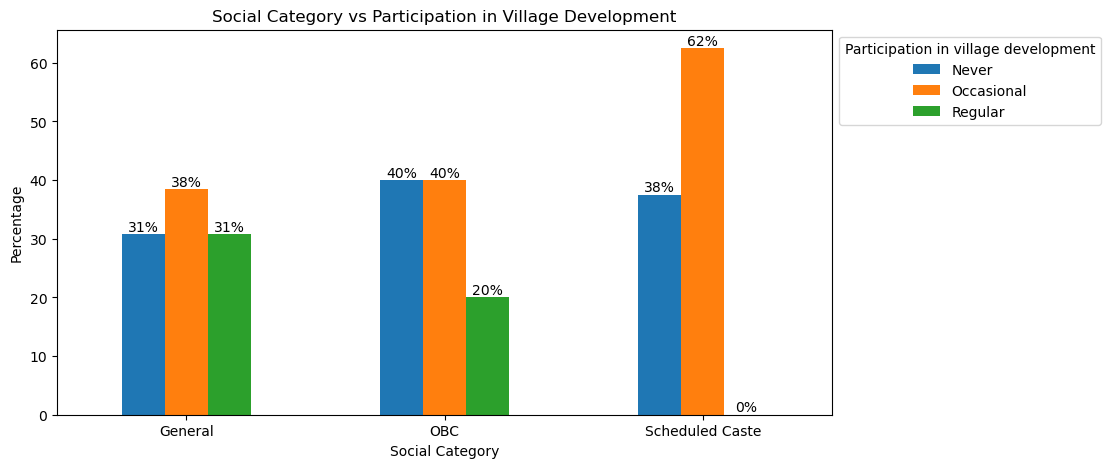

In [180]:
bars = social_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Social Category vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Skill-Demand Mismatch for Livelihoods

# 1. Skill Demand vs Current Occupation (Gap Analysis)

In [181]:
skill_occupation = pd.crosstab(df['Main Occupation'], df['Skills required'])
skill_occupation

Skills required,Agriculture,"Agriculture, Tailoring, Computer, Driving",Computer,Driving,Electrical,"Electrical, Driving",Tailoring,"Tailoring, Driving"
Main Occupation,,,,,,,,
Agriculture,17,1,1,0,0,0,0,0
"Agriculture, Service",1,1,0,0,0,0,0,0
Business,1,0,2,0,0,0,0,1
Labour,3,0,0,1,0,1,0,0
Service,7,0,1,3,2,0,1,0


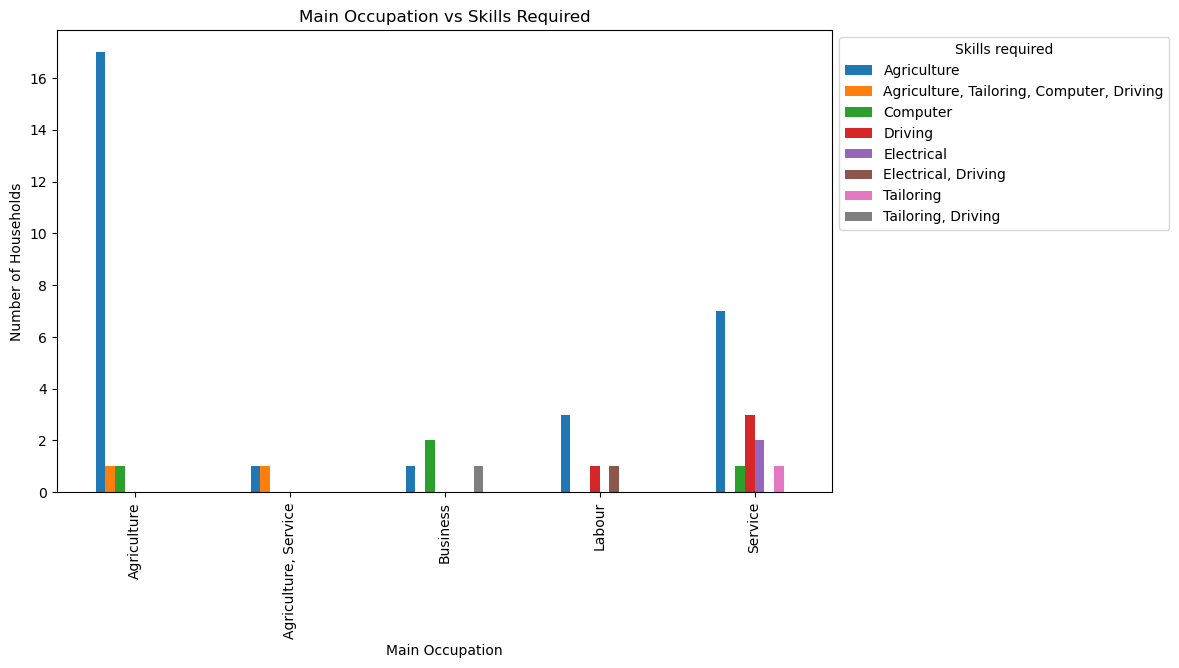

In [182]:
skill_occupation.plot(kind='bar', figsize=(10,6))
plt.title("Main Occupation vs Skills Required")
plt.ylabel("Number of Households")
plt.xlabel("Main Occupation")
plt.legend(title="Skills required", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

# 2. Skill Training vs Household Income (Future Readiness)

In [183]:
skill_income = round(pd.crosstab(df['Skill-trained member in household'], df['Approx. Annual Household Income'], normalize='index') * 100, 2)
skill_income

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Skill-trained member in household,,,,
No,68.75,12.50,18.75,0.00
Yes,39.29,35.71,14.29,10.71


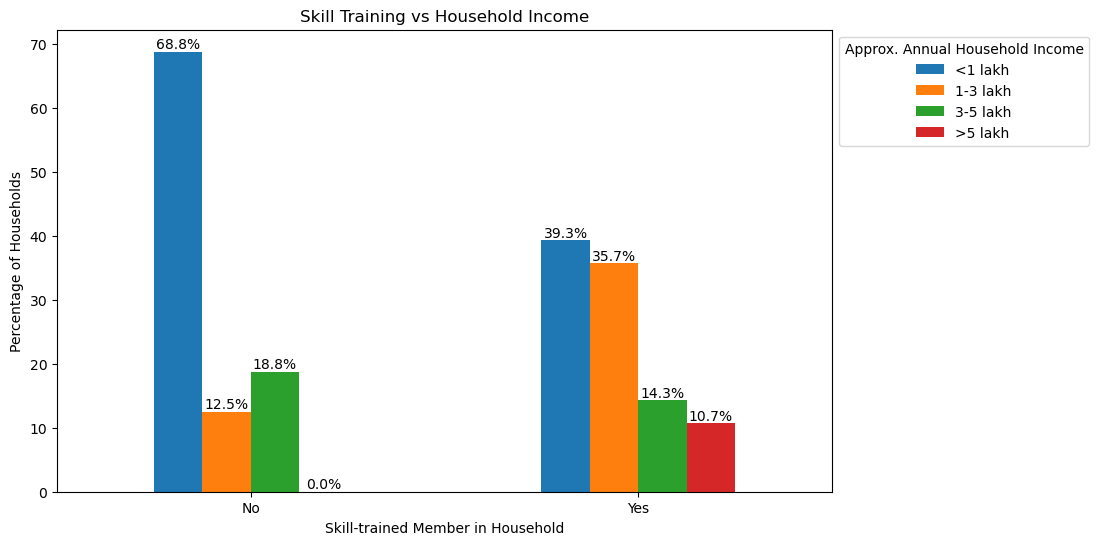

In [184]:
bars = skill_income.plot(kind='bar', figsize=(10,6))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Skill Training vs Household Income")
plt.ylabel("Percentage of Households")
plt.xlabel("Skill-trained Member in Household")
plt.legend(title="Approx. Annual Household Income", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Skills Required Distribution

In [185]:
skills_demand = df['Skills required'].value_counts()
skills_demand

Skills required
Agriculture                                  29
Driving                                       4
Computer                                      4
Agriculture, Tailoring, Computer, Driving     2
Electrical                                    2
Tailoring                                     1
Tailoring, Driving                            1
Electrical, Driving                           1
Name: count, dtype: int64

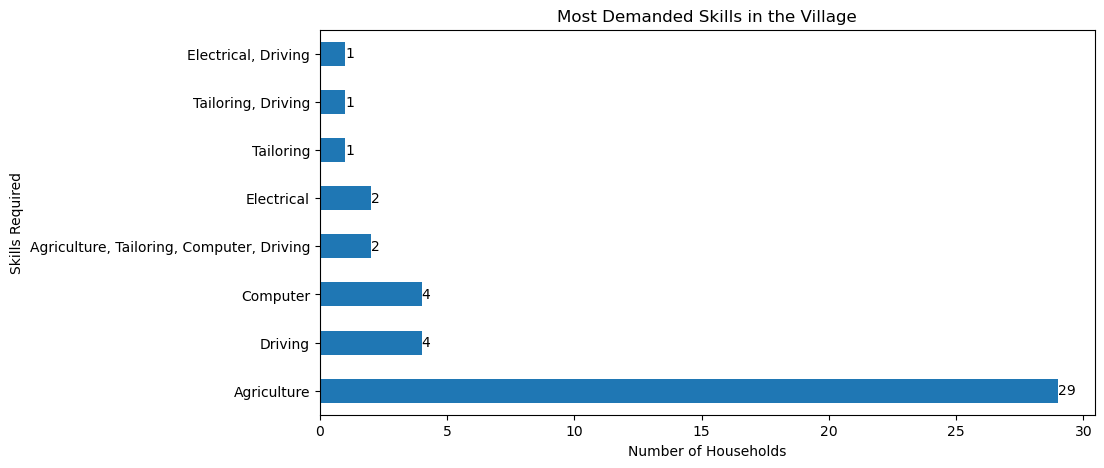

In [186]:
bars = skills_demand.plot(kind='barh', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_width(),
             bar.get_y()+ bar.get_height()/2,
             f'{bar.get_width()}',
             va='center')
plt.title("Most Demanded Skills in the Village")
plt.xlabel("Number of Households")
plt.ylabel("Skills Required")
plt.show()